#  Tiempo esperado sobre mapas de probabilidad

Juan Pedro Llerena

jp.llerena@uah.es

---

##  Descripción general

Este cuaderno tiene como objetivo representar visualmente un **mapa de probabilidad** en forma de matriz, e ir actualizando su estado paso a paso conforme se simula el avance por determinadas celdas. Al mismo tiempo, se calcula el **tiempo esperado** (Expected Time, ET) que se tarda en recorrer esas celdas, suponiendo que cada celda contiene un valor que representa la probabilidad de detenerse (o el coste de transitarla).

---

## Formulación matemática

El objetivo principal del problema de MTS es minimizar el **tiempo esperado** de detección del objetivo ($ET$). En este trabajo, el valor esperado del tiempo de detección para las trayectorias dadas, denotado como $ET(s_{0:t}^{1:U})$, se selecciona como el criterio de función objetivo a minimizar $f(\mathbf{x})$. Suponiendo que los UAVs realizan mediciones en instantes de tiempo discretos, $ET(s_{0:t}^{1:U})$ puede calcularse utilizando las siguientes ecuaciones. Para expresar el tiempo esperado en unidades de tiempo en lugar de pasos de tiempo, el valor obtenido debe multiplicarse por el intervalo de tiempo $\Delta$ entre dos mediciones consecutivas.

$$ ET(s_{1:U}^{0:\infty}) = \sum_{t=0}^{\infty} P(z_{1:U}^{0:t} = \bar{D} | s_{1:U}^{0:t}) = \sum_{t=0}^{\infty} \sum_{\nu^t \in G_\Omega} \tilde{b}(\nu^t)
$$

donde:
$$ \tilde{b}(\nu^t) = \prod_{u=1:U} P(z_t^u = \bar{D} | \nu^t, s_u^t) \sum_{\nu^{t-1} \in G_\Omega} P(\nu^t | \nu^{t-1}) \tilde{b}(\nu^{t-1}) $$

Dado un conjunto ordenado de pasos $ S = \{s_1, s_2, ..., s_k\}$, donde cada $ s_i \in \{1, 2, ..., mn\} $ representa una posición en la matriz en formato lineal (índice plano), el **tiempo esperado** se define como:



donde $s_u^{t+1} = f(s_u^t, c_u^t) $ es la posición del UAV $u$ en el paso de tiempo $t+1$, $s_u^t$ representa la posición previa del UAV $u$ en el paso de tiempo $t$, y $c_u^t$ es la acción de control aplicada en ese instante. Recordemos que $f(s_u^t, c_u^t)$ es el modelo determinista de la dinámica del UAV.

El uso de modelos dinámicos de UAV permite a los algoritmos de búsqueda probabilística (\textit{PS, Probabilistic Search}) definir las trayectorias de los UAVs ya sea mediante las posiciones $s_{1:U}^{0:t}$ de los UAVs, o mediante las posiciones iniciales $s_{1:U}^0$ de los UAVs y la secuencia de acciones de control $c_{1:U}^{1:t}$. Esto habilita tomar como variables de decisión las trayectorias de búsqueda o las secuencias de acciones de control, aprovechando la posibilidad de obtener indirectamente trayectorias que cumplen con las restricciones dinámicas implícitas en $f(s_u^t, c_u^t)$.


---


# Imports

In [1066]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Rectangle
from matplotlib import rc
from IPython.display import HTML
from scipy.signal import convolve2d
import os
import random
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Métodos y Funciones

In [1067]:
# ==== Función de actualización de probabilidades ====
def update_probabilities(bk, pos_agente):
    """
    Actualiza dinámicamente una matriz de probabilidades eliminando la celda del agente
    y normalizando el resto de valores para que la suma total sea 1.

    Parámetros:
    -----------
    bk : np.array
        Matriz de probabilidades (puede estar parcialmente modificada por pasos anteriores).

    pos_agente : int
        Índice plano (0-based) de la celda actual del agente (fila * n_columnas + columna).

    Retorna:
    --------
    new_bk : np.array
        Matriz de probabilidades actualizada:
        - La celda del agente se pone a 0.
        - El resto de probabilidades se reescalan proporcionalmente para conservar la suma total.
    """

    # Obtener dimensiones de la matriz
    rows, cols = bk.shape

    # Calcular coordenadas (x, y) a partir del índice plano
    x, y = divmod(pos_agente, cols)

    # Crear una copia para evitar modificar la original
    new_bk = np.copy(bk)

    # Eliminar (poner a cero) la probabilidad de la celda actual del agente
    new_bk[x, y] = 0

    # Calcular la suma total restante
    total = np.sum(new_bk)

    # Si hay probabilidad restante, normalizar el resto del mapa
    if total > 0:
        new_bk = new_bk / total

    # Devolver el mapa actualizado
    return new_bk

# ==== Función de actualización de probabilidades ====
def rbf(bk, pos_agente, pos_obj, p_transicion, dmax, pdmax, sigma, movimientos_objetivo=None):
    """
    Calcula una iteración del filtro bayesiano recursivo:
        Actualizar la creencia, simular el movimiento del objetivo y comprobar si
        el agente lo ha encontrado
    Parámetros:
        bk: np.array, mapa de probabilidad
        pos_agente: posición del agente (índice plano o tupla (x, y))
        pos_obj: tupla (x, y), posición del objetivo
        p_transicion: matriz de transición
        dmax: distancia máxima de detección
        pdmax: probabilidad de detección máxima
        sigma: desviación estándar del sensor
        movimientos_objetivo: lista opcional de movimientos permitidos
    Devuelve:
        new_bk: mapa de probabilidad actualizado
        found: Booleano, True si el agente detecta al objetivo
    """

    # Convertir índice plano a coordenadas si es necesario
    if isinstance(pos_agente, int) or isinstance(pos_agente, np.integer):
        filas, columnas = bk.shape
        pos_agente = divmod(pos_agente, columnas)

    c_x, c_y = pos_agente

    # Predicción del movimiento del objetivo
    bk = convolve2d(bk, p_transicion, mode="same")
    bk = bk / np.sum(bk)

    # Crear rejilla de coordenadas para cálculo de distancia
    coords = np.mgrid[0 : bk.shape[0], 0 : bk.shape[1]]
    distance = np.sqrt((coords[0] - c_x) ** 2 + (coords[1] - c_y) ** 2)

    # Modelo de sensor (detección probabilística decreciente con la distancia)
    obs = pdmax * np.exp(-sigma * (distance / dmax) ** 2)

    # Actualización bayesiana: eliminar probabilidad en función de la observación
    bk = (1 - obs) * bk
    bk = bk / np.sum(bk)

    # Comprobar si el objetivo está dentro del rango de detección
    found = (
        np.abs(c_x - pos_obj[0]) <= dmax and
        np.abs(c_y - pos_obj[1]) <= dmax
    )

    return bk, found

# ==== Actualización con filtro recursivo bayesiano ====
def update_probabilitiesRBF(
    bk,
    pos_agente,
    pos_obj=None,
    p_transicion=None,
    dmax=None,
    pdmax=None,
    sigma=None,
    movimientos_objetivo=None
):
    """
    Actualiza la matriz de probabilidades eliminando la celda del agente y normalizando.
    Si se proporcionan parámetros del objetivo, aplica un filtro bayesiano recursivo (RBF).

    Parámetros:
    - bk : np.array              → Mapa de creencias actual
    - pos_agente : int o tuple  → Posición del agente (índice plano o coordenadas)
    - pos_obj : tuple (opcional) → Posición actual del objetivo
    - p_transicion : np.array    → Matriz de transición del objetivo
    - dmax, pdmax, sigma : float → Parámetros del sensor
    - movimientos_objetivo : list[tuple[int,int]] → Movimientos permitidos del objetivo (opcional)

    Retorna:
    - new_bk : np.array → Mapa actualizado
    """

    # Convertir índice plano a coordenadas si es necesario
    if isinstance(pos_agente, int):
        filas, cols = bk.shape
        pos_agente = divmod(pos_agente, cols)

    # Si se proporcionan parámetros del objetivo, usar filtro bayesiano
    if all(v is not None for v in [pos_obj, p_transicion, dmax, pdmax, sigma]):
        new_bk, _ = rbf(
            bk,
            pos_agente,
            pos_obj,
            p_transicion,
            dmax,
            pdmax,
            sigma,
            movimientos_objetivo
        )
        return new_bk

    # Actualización simple: eliminar creencia en celda visitada y normalizar
    new_bk = np.copy(bk)
    x, y = pos_agente
    new_bk[x, y] = 0
    total = np.sum(new_bk)
    if total > 0:
        new_bk /= total

    return new_bk

# --- Expected Time (ET) ---
def ET_step(bk, current_pos):
    """
    Calcula el Expected Time (ET) de un paso:
    suma de las probabilidades de todas las celdas excepto la actual.
    """
    rows, cols = bk.shape
    return sum(
        bk[x, y]
        for x in range(rows)
        for y in range(cols)
        if (x, y) != current_pos
    )

def ET(trayectoria, matriz_inicial, actualizar=False, modo_actualizacion='simple', parametros_rbf=None):
    bk = matriz_inicial.copy()
    expected_time = 0
    data = []

    for paso in trayectoria:
        paso_index = paso - 1
        i, j = divmod(paso_index, bk.shape[1])
        current_pos = (i, j)

        et_paso = ET_step(bk, current_pos)
        expected_time += et_paso

        celda_val = matriz_inicial[i, j]
        texto_celda = f"{paso}\n{celda_val:.2f}"

        if actualizar:
            if modo_actualizacion == 'simple':
                bk = update_probabilities(bk, paso_index)
            elif modo_actualizacion == 'rbf' and parametros_rbf is not None:
                pdmax = min(parametros_rbf.get('pdmax', 1), 0.9999)
                bk = update_probabilitiesRBF(
                    bk,
                    paso_index,
                    pos_obj=parametros_rbf['pos_obj'],
                    p_transicion=parametros_rbf['p_transicion'],
                    dmax=parametros_rbf['dmax'],
                    pdmax=pdmax,
                    sigma=parametros_rbf['sigma']
                )
        else:
            bk[i, j] = 0

        data.append({
            "Paso": paso,
            "Celda Índice": paso,
            "Valor Celda": celda_val,
            "Expected Time del paso": et_paso,
            "Expected Time acumulado": expected_time,
            "Texto celda": texto_celda,
            "Bk": bk.copy()
        })

    return pd.DataFrame(data), expected_time

# --- Discounted Time Reward (DTR) corregido y alineado ---
def step_DTR(matriz, pos_actual, paso, gamma=0.95):
    i, j = pos_actual
    reward = (gamma ** (paso - 1)) * matriz[i, j]  # gamma^(t-1) como en literatura
    idx_celda = i * matriz.shape[1] + j + 1
    texto_celda = f"{idx_celda}\n{matriz[i, j]:.2f}"
    return reward, idx_celda, texto_celda

def DTR(trayectoria, matriz_inicial, gamma=0.95, actualizar=False, modo_actualizacion='simple', parametros_rbf=None):
    bk = matriz_inicial.copy().astype(float)
    dtr_total = 0
    data = []

    for idx, paso in enumerate(trayectoria, start=1):
        paso_index = paso - 1
        i, j = divmod(paso_index, bk.shape[1])
        prob_paso = bk[i, j]  # probabilidad actual en la celda

        reward = (gamma ** (idx - 1)) * prob_paso  # gamma^(t-1)
        dtr_total += reward

        texto_celda = f"{paso}\n{matriz_inicial[i,j]:.2f}"

        if actualizar:
            if modo_actualizacion == 'simple':
                bk = update_probabilities(bk, paso_index)
            elif modo_actualizacion == 'rbf' and parametros_rbf is not None:
                pdmax = min(parametros_rbf.get('pdmax', 1), 0.9999)
                bk = update_probabilitiesRBF(
                    bk,
                    paso_index,
                    pos_obj=parametros_rbf['pos_obj'],
                    p_transicion=parametros_rbf['p_transicion'],
                    dmax=parametros_rbf['dmax'],
                    pdmax=pdmax,
                    sigma=parametros_rbf['sigma']
                )
        else:
            bk[i, j] = 0.0

        data.append({
            "Paso": idx,
            "Celda Índice": paso,
            "Valor Celda": prob_paso,
            "Reward paso": reward,
            "DTR acumulado": dtr_total,
            "Texto celda": texto_celda,
            "Bk": bk.copy()
        })

    return pd.DataFrame(data), dtr_total


# --- Maximum Slope (MS) ---
def step_MS(matriz, pos_actual, pos_anterior):
    i, j = pos_actual
    ia, ja = pos_anterior
    # Pendiente normalizada (alineada con la literatura)
    distancia = np.hypot(i - ia, j - ja)
    if distancia == 0:
        slope = 0
    else:
        slope = (matriz[i, j] - matriz[ia, ja]) / distancia
    idx_celda = i * matriz.shape[1] + j + 1
    texto_celda = f"{idx_celda}\n{matriz[i, j]:.2f}"
    return slope, idx_celda, texto_celda


def MS(trayectoria, matriz_inicial, actualizar=False, modo_actualizacion='simple', parametros_rbf=None):
    bk = matriz_inicial.copy()
    max_slope_total = -np.inf
    data = []

    for idx, paso in enumerate(trayectoria):
        paso_index = paso - 1
        i, j = divmod(paso_index, bk.shape[1])

        valor_actual = bk[i, j]  # ⚠️ tomar valor antes de actualizar o poner a 0

        # --- Pendiente entre pasos consecutivos (definición formal) ---
        if idx > 0:
            paso_anterior = trayectoria[idx - 1] - 1
            ia, ja = divmod(paso_anterior, bk.shape[1])
            distancia = np.hypot(i - ia, j - ja)
            if distancia > 0:
                slope = (bk[i, j] - bk[ia, ja]) / distancia
            else:
                slope = 0
        else:
            slope = 0  # primer paso: sin pendiente previa

        # Solo pendientes positivas (ascendentes)
        slope = max(0, slope)

        # Actualizar máximo global si corresponde
        if slope > max_slope_total:
            max_slope_total = slope

        # --- Actualización del mapa de creencias si corresponde ---
        if actualizar:
            if modo_actualizacion == 'simple':
                bk = update_probabilities(bk, paso_index)
            elif modo_actualizacion == 'rbf' and parametros_rbf is not None:
                pdmax = min(parametros_rbf.get('pdmax', 1), 0.9999)
                bk = update_probabilitiesRBF(
                    bk,
                    paso_index,
                    pos_obj=parametros_rbf['pos_obj'],
                    p_transicion=parametros_rbf['p_transicion'],
                    dmax=parametros_rbf['dmax'],
                    pdmax=pdmax,
                    sigma=parametros_rbf['sigma']
                )
        else:
            bk[i, j] = 0  # ⚠️ solo después de calcular pendiente

        texto_celda = f"{paso}\n{valor_actual:.2f}"

        # --- Guardar datos de evolución ---
        data.append({
            "Paso": idx + 1,
            "Celda Índice": paso,
            "Valor Celda": valor_actual,
            "Slope del paso": slope,
            "Max Slope": max_slope_total,
            "Texto celda": texto_celda,
            "Bk": bk.copy()
        })

    return pd.DataFrame(data), max_slope_total



# --- Minimum Entropy (ME) ---
def entropy(p):
    p = p.flatten()
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def minimum_entropy(trayectoria, matriz_inicial, actualizar=False, modo_actualizacion='simple', parametros_rbf=None):
    bk = matriz_inicial.copy()
    mapa_inicial = bk.copy()
    filas, columnas = bk.shape
    data = []

    for idx, paso in enumerate(trayectoria):
        paso_index = paso - 1
        i, j = divmod(paso_index, columnas)
        celda_val = bk[i, j]

        if actualizar:
            if modo_actualizacion == 'simple':
                bk = update_probabilities(bk, paso_index)
            elif modo_actualizacion == 'rbf' and parametros_rbf is not None:
                pdmax = min(parametros_rbf.get('pdmax', 1), 0.9999)
                bk = update_probabilitiesRBF(
                    bk,
                    paso_index,
                    pos_obj=parametros_rbf['pos_obj'],
                    p_transicion=parametros_rbf['p_transicion'],
                    dmax=parametros_rbf['dmax'],
                    pdmax=pdmax,
                    sigma=parametros_rbf['sigma']
                )
        else:
            bk[i, j] = 0

        entropia_paso = entropy(bk)
        texto_celda_actual = f"Celda ({i},{j})"
        pendientes = trayectoria[idx+1:]
        texto_celda_pendiente = ','.join(str(p) for p in pendientes) if pendientes else "Ninguna"

        data.append({
            "Paso": idx,
            "Celda Índice": paso,
            "Valor Celda": celda_val,
            "Entropia Paso": entropia_paso,
            "Texto Celda Actual": texto_celda_actual,
            "Texto Celda Pendiente": texto_celda_pendiente,
            "Bk": bk.copy()
        })

    entropia_inicial = entropy(mapa_inicial)
    entropia_final = entropy(bk)

    return pd.DataFrame(data), entropia_final, entropia_inicial


# Funciones para animar las trayectorias
def animation_1_Trajectory(df_trayectoria, ax, im, title, text_objects, border, matriz_original):
    tray = df_trayectoria["Celda Índice"].tolist()

    # Buscar columna de métrica acumulada: primero "acumulado"
    acum_col = next(
        (col for col in df_trayectoria.columns if "acumulado" in col.lower()), None
    )

    # Si no hay, buscar "máxima"
    if acum_col is None:
        acum_col = next(
            (col for col in df_trayectoria.columns if "max" in col.lower()), None
        )

    # Si tampoco hay, buscar "entropia"
    if acum_col is None:
        acum_col = next(
            (col for col in df_trayectoria.columns if "entropia" in col.lower()), None
        )

    # Preparar lista de valores para mostrar en título o None
    metricas_pasos = df_trayectoria[acum_col].tolist() if acum_col else [None] * len(df_trayectoria)
    bk_series = df_trayectoria["Bk"]

    def animate(frame):
        nonlocal text_objects, border

        # Limpiar textos anteriores
        for txt in text_objects:
            txt.remove()
        text_objects = []

        # Eliminar borde anterior
        if border is not None:
            border.remove()

        paso = tray[frame]
        mapa = bk_series.iloc[frame]
        i, j = divmod(paso - 1, mapa.shape[1])
        im.set_data(mapa)

        # Dibujar textos por celda
        for x in range(mapa.shape[0]):
            for y in range(mapa.shape[1]):
                idx = x * mapa.shape[1] + y + 1
                texto = f"{idx}\n{mapa[x, y]:.2f}"
                if (x, y) == (i, j):
                    texto += "\nAGENTE"
                color = 'white' if (mapa[x, y] < 0.10 or mapa[x, y] > 0.25) else 'black'
                txt = ax.text(y, x, texto, ha="center", va="center", color=color)
                text_objects.append(txt)

        # Añadir borde azul para el agente
        border = Rectangle((j - 0.5, i - 0.5), 1, 1, linewidth=3, edgecolor='blue', facecolor='none')
        ax.add_patch(border)

        # Título dinámico con métrica si hay
        if metricas_pasos[frame] is not None:
            title.set_text(f"Paso {frame + 1}: Celda {paso} | {acum_col}: {metricas_pasos[frame]:.2f}")
        else:
            title.set_text(f"Paso {frame + 1}: Celda {paso}")

        ax.set_xticks([])
        ax.set_yticks([])

    return animate

def animation_2_Trajectories(df_trayectoria_A, df_trayectoria_B,
                             ax1, ax2, im1, im2, title1, title2,
                             text_objects_A, text_objects_B, border_A, border_B):
    tray_A = df_trayectoria_A["Celda Índice"].tolist()
    tray_B = df_trayectoria_B["Celda Índice"].tolist()

    # Detectar automáticamente la columna de métrica acumulada en cada trayectoria
    acum_col_A = next((col for col in df_trayectoria_A.columns if "acumulado" in col.lower()), None)
    acum_col_B = next((col for col in df_trayectoria_B.columns if "acumulado" in col.lower()), None)

    et_A_pasos = df_trayectoria_A[acum_col_A].tolist() if acum_col_A else [None] * len(df_trayectoria_A)
    et_B_pasos = df_trayectoria_B[acum_col_B].tolist() if acum_col_B else [None] * len(df_trayectoria_B)

    bk_A_series = df_trayectoria_A["Bk"]
    bk_B_series = df_trayectoria_B["Bk"]

    def animate(frame):
        nonlocal text_objects_A, text_objects_B, border_A, border_B

        # Limpiar textos anteriores
        for txt in text_objects_A:
            txt.remove()
        for txt in text_objects_B:
            txt.remove()
        text_objects_A, text_objects_B = [], []

        # Eliminar bordes anteriores
        if border_A:
            border_A.remove()
        if border_B:
            border_B.remove()

        # ----- Trayectoria A -----
        if frame < len(tray_A):
            paso_A = tray_A[frame]
            mapa_A = bk_A_series.iloc[frame]
            i_A, j_A = divmod(paso_A - 1, mapa_A.shape[1])
            im1.set_data(mapa_A)

            for x in range(mapa_A.shape[0]):
                for y in range(mapa_A.shape[1]):
                    idx = x * mapa_A.shape[1] + y + 1
                    texto = f"{idx}\n{mapa_A[x, y]:.2f}"
                    if (x, y) == (i_A, j_A):
                        texto += "\nAGENTE"
                    color = 'white' if (mapa_A[x, y] < 0.10 or mapa_A[x, y] > 0.25) else 'black'
                    txt = ax1.text(y, x, texto, ha="center", va="center", color=color)
                    text_objects_A.append(txt)

            border_A = Rectangle((j_A - 0.5, i_A - 0.5), 1, 1, linewidth=3, edgecolor='blue', facecolor='none')
            ax1.add_patch(border_A)

            if et_A_pasos[frame] is not None:
                title1.set_text(f"Trayectoria A - Paso {frame + 1} | {acum_col_A}: {et_A_pasos[frame]:.2f}")
            else:
                title1.set_text(f"Trayectoria A - Paso {frame + 1}")

        # ----- Trayectoria B -----
        if frame < len(tray_B):
            paso_B = tray_B[frame]
            mapa_B = bk_B_series.iloc[frame]
            i_B, j_B = divmod(paso_B - 1, mapa_B.shape[1])
            im2.set_data(mapa_B)

            for x in range(mapa_B.shape[0]):
                for y in range(mapa_B.shape[1]):
                    idx = x * mapa_B.shape[1] + y + 1
                    texto = f"{idx}\n{mapa_B[x, y]:.2f}"
                    if (x, y) == (i_B, j_B):
                        texto += "\nAGENTE"
                    color = 'white' if (mapa_B[x, y] < 0.10 or mapa_B[x, y] > 0.25) else 'black'
                    txt = ax2.text(y, x, texto, ha="center", va="center", color=color)
                    text_objects_B.append(txt)

            border_B = Rectangle((j_B - 0.5, i_B - 0.5), 1, 1, linewidth=3, edgecolor='blue', facecolor='none')
            ax2.add_patch(border_B)

            if et_B_pasos[frame] is not None:
                title2.set_text(f"Trayectoria B - Paso {frame + 1} | {acum_col_B}: {et_B_pasos[frame]:.2f}")
            else:
                title2.set_text(f"Trayectoria B - Paso {frame + 1}")

        ax1.set_xticks([]), ax1.set_yticks([])
        ax2.set_xticks([]), ax2.set_yticks([])

    return animate

def save_steps_figures(df_greedy, ruta=None, nombre_base="greedy"):
    if ruta is None:
        ruta = f"Figures_{nombre_base}"
    if not os.path.exists(ruta):
        os.makedirs(ruta)

    vmax_global = np.max(df_greedy.iloc[0]["Bk"])

    for idx, row in df_greedy.iterrows():
        mapa = row["Bk"]
        paso = row["Paso"]
        celda_index = row["Celda Índice"]
        et_acumulado = row.get("Expected Time acumulado", None)

        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(mapa, cmap="jet", vmin=0, vmax=vmax_global)
        plt.colorbar(im)

        rows, cols = mapa.shape
        i, j = divmod(celda_index - 1, cols)

        for x in range(rows):
            for y in range(cols):
                idx_celda = x * cols + y + 1
                texto = f"{idx_celda}\n{mapa[x, y]:.2f}"
                if (x, y) == (i, j):
                    texto += "\nAGENTE"
                color = 'white' if (mapa[x, y] < 0.10 or mapa[x, y] > 0.25) else 'black'
                ax.text(y, x, texto, ha="center", va="center", color=color)

        border = Rectangle((j - 0.5, i - 0.5), 1, 1, linewidth=3, edgecolor='blue', facecolor='none')
        ax.add_patch(border)

        if et_acumulado is not None:
            ax.set_title(f"Paso {paso}: Celda {celda_index} | ET acumulado: {et_acumulado:.2f}")
        else:
            ax.set_title(f"Paso {paso}: Celda {celda_index}")

        ax.set_xticks([])
        ax.set_yticks([])

        nombre_archivo = f"{nombre_base}_paso{paso}.svg"
        ruta_completa = os.path.join(ruta, nombre_archivo)
        plt.savefig(ruta_completa, format="svg", bbox_inches="tight")
        plt.close(fig)

    print(f"Imágenes guardadas correctamente en: '{ruta}'")

In [1068]:
# ==== MATRIZ DE PROBABILIDADES ====
matriz = np.array([
    [0.10, 0.15, 0.10],
    [0.30, 0.20, 0.00],
    [0.10, 0.00, 0.05]
])

# ==== Trayec=toria que queremos visualizar ====
trayectoria_A = [1, 4, 5, 2, 3]  # ET debe ser 2.30
trayectoria_B = [1, 2, 5, 4, 7]  # ET debe ser 2.60

Actualizar = False

# ET
df_et_A, et_total_A = ET(trayectoria_A, matriz, Actualizar)
df_et_B, et_total_B = ET(trayectoria_B, matriz, Actualizar)

# DTR
df_dtr_A, dtr_total_A = DTR(trayectoria_A, matriz, gamma=0.95, actualizar=Actualizar)
df_dtr_B, dtr_total_B = DTR(trayectoria_B, matriz, gamma=0.95, actualizar=Actualizar)

# MS
df_ms_A, ms_A = MS(trayectoria_A, matriz, actualizar=Actualizar)
df_ms_B, ms_B = MS(trayectoria_B, matriz, actualizar=Actualizar)

# ME (entropía final tras aplicar la trayectoria)
df_me_A, me_A, h0_A = minimum_entropy(trayectoria_A, matriz, actualizar=Actualizar)
df_me_B, me_B, h0_B = minimum_entropy(trayectoria_B, matriz, actualizar=Actualizar)

print("==== Métricas trayectorias ====")
print("\nTrayectoria A:")
print(f"ET total       = {et_total_A:.2f}")
print(f"DTR total      = {dtr_total_A:.4f}")
print(f"Max Slope     = {ms_A:.4f}")
print(f"Entropía final = {me_A:.4f} (inicial: {h0_A:.4f})")

print("\nTrayectoria B:")
print(f"ET total       = {et_total_B:.2f}")
print(f"DTR total      = {dtr_total_B:.4f}")
print(f"Max Slope     = {ms_B:.4f}")
print(f"Entropía final = {me_B:.4f} (inicial: {h0_B:.4f})")

==== Métricas trayectorias ====

Trayectoria A:
ET total       = 2.30
DTR total      = 0.7756
Max Slope     = 0.3000
Entropía final = 0.5483 (inicial: 2.6087)

Trayectoria B:
ET total       = 2.60
DTR total      = 0.7617
Max Slope     = 0.3000
Entropía final = 0.5483 (inicial: 2.6087)


## Animación ET trayectoria A y trayectoria B

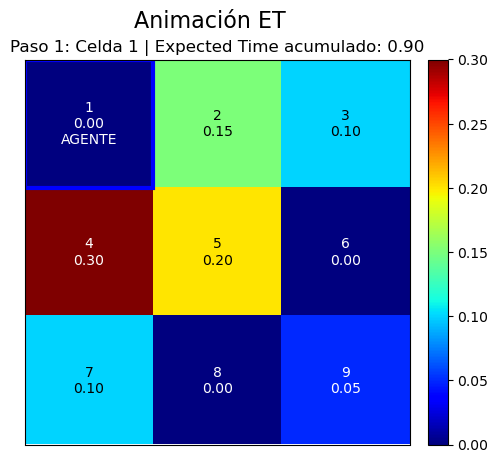

In [1069]:
# === ET ===
df_anim_et = df_et_A  # o df_et_B
bk_series_et = df_anim_et["Bk"]

fig_et, ax_et = plt.subplots(figsize=(6, 5))
fig_et.suptitle("Animación ET", fontsize=16)
im_et = ax_et.imshow(bk_series_et.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_et.colorbar(im_et, ax=ax_et, fraction=0.046, pad=0.04)
title_et = ax_et.set_title("")
text_objects_et = []
border_et = None

anim_func_et = animation_1_Trajectory(df_anim_et, ax_et, im_et, title_et, text_objects_et, border_et, matriz)
ani_et = FuncAnimation(fig_et, anim_func_et, frames=len(df_anim_et), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_et.to_html5_video())

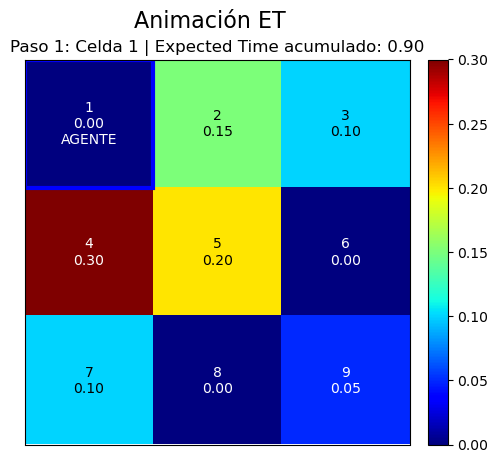

In [1070]:
# === ET ===
df_anim_et = df_et_B  # o df_et_A
bk_series_et = df_anim_et["Bk"]

fig_et, ax_et = plt.subplots(figsize=(6, 5))
fig_et.suptitle("Animación ET", fontsize=16)
im_et = ax_et.imshow(bk_series_et.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_et.colorbar(im_et, ax=ax_et, fraction=0.046, pad=0.04)
title_et = ax_et.set_title("")
text_objects_et = []
border_et = None

anim_func_et = animation_1_Trajectory(df_anim_et, ax_et, im_et, title_et, text_objects_et, border_et, matriz)
ani_et = FuncAnimation(fig_et, anim_func_et, frames=len(df_anim_et), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_et.to_html5_video())

## Animación DTR trayectoria A y trayectoria B

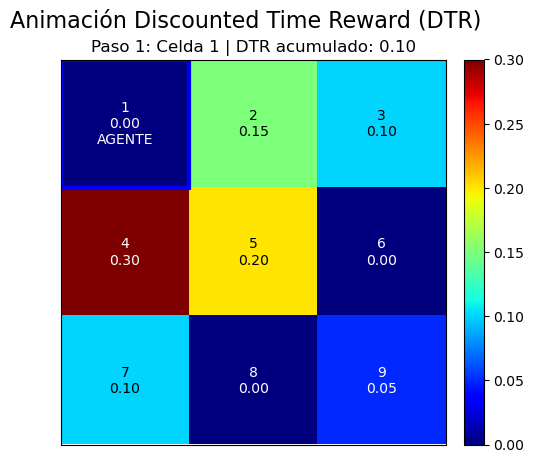

In [1071]:
# === DTR ===
df_anim_dtr = df_dtr_A  # o df_dtr_B
bk_series_dtr = df_anim_dtr["Bk"]

fig_dtr, ax_dtr = plt.subplots(figsize=(6, 5))
fig_dtr.suptitle("Animación Discounted Time Reward (DTR)", fontsize=16)
im_dtr = ax_dtr.imshow(bk_series_dtr.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_dtr.colorbar(im_dtr, ax=ax_dtr, fraction=0.046, pad=0.04)
title_dtr = ax_dtr.set_title("")
text_objects_dtr = []
border_dtr = None

anim_func_dtr = animation_1_Trajectory(df_anim_dtr, ax_dtr, im_dtr, title_dtr, text_objects_dtr, border_dtr, matriz)
ani_dtr = FuncAnimation(fig_dtr, anim_func_dtr, frames=len(df_anim_dtr), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_dtr.to_html5_video())

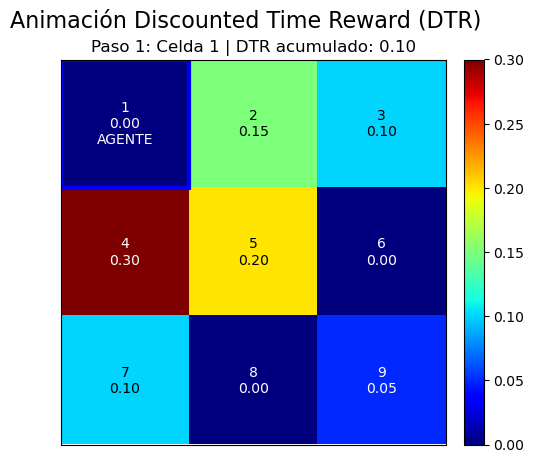

In [1072]:
# === DTR ===
df_anim_dtr = df_dtr_B  # o df_dtr_A
bk_series_dtr = df_anim_dtr["Bk"]

fig_dtr, ax_dtr = plt.subplots(figsize=(6, 5))
fig_dtr.suptitle("Animación Discounted Time Reward (DTR)", fontsize=16)
im_dtr = ax_dtr.imshow(bk_series_dtr.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_dtr.colorbar(im_dtr, ax=ax_dtr, fraction=0.046, pad=0.04)
title_dtr = ax_dtr.set_title("")
text_objects_dtr = []
border_dtr = None

anim_func_dtr = animation_1_Trajectory(df_anim_dtr, ax_dtr, im_dtr, title_dtr, text_objects_dtr, border_dtr, matriz)
ani_dtr = FuncAnimation(fig_dtr, anim_func_dtr, frames=len(df_anim_dtr), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_dtr.to_html5_video())

## Animación MS trayectoria A y trayectoria B

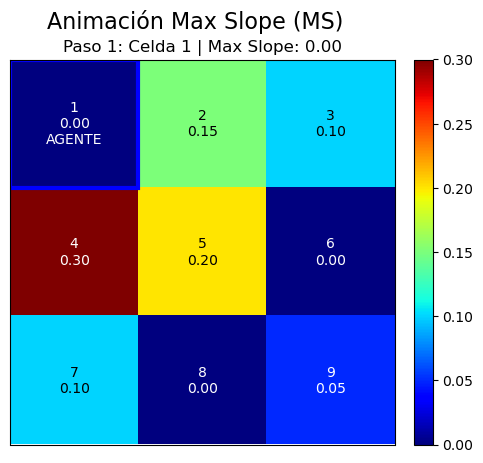

In [1073]:
# === MS ===
df_anim_ms = df_ms_A  # o df_ms_B
bk_series_ms = df_anim_ms["Bk"]

fig_ms, ax_ms = plt.subplots(figsize=(6, 5))
fig_ms.suptitle("Animación Max Slope (MS)", fontsize=16)
im_ms = ax_ms.imshow(bk_series_ms.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_ms.colorbar(im_ms, ax=ax_ms, fraction=0.046, pad=0.04)
title_ms = ax_ms.set_title("")
text_objects_ms = []
border_ms = None

anim_func_ms = animation_1_Trajectory(df_anim_ms, ax_ms, im_ms, title_ms, text_objects_ms, border_ms, matriz)
ani_ms = FuncAnimation(fig_ms, anim_func_ms, frames=len(df_anim_ms), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_ms.to_html5_video())

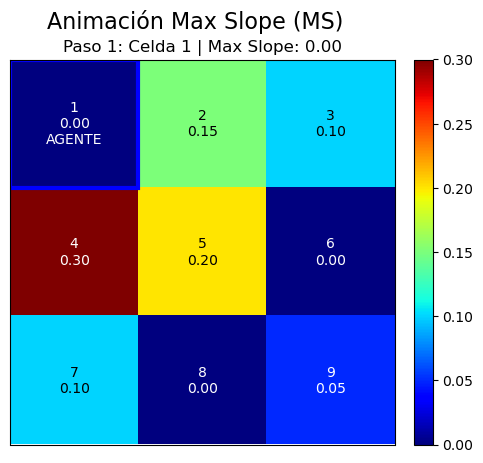

In [1074]:
# === MS ===
df_anim_ms = df_ms_B  # o df_ms_B
bk_series_ms = df_anim_ms["Bk"]

fig_ms, ax_ms = plt.subplots(figsize=(6, 5))
fig_ms.suptitle("Animación Max Slope (MS)", fontsize=16)
im_ms = ax_ms.imshow(bk_series_ms.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_ms.colorbar(im_ms, ax=ax_ms, fraction=0.046, pad=0.04)
title_ms = ax_ms.set_title("")
text_objects_ms = []
border_ms = None

anim_func_ms = animation_1_Trajectory(df_anim_ms, ax_ms, im_ms, title_ms, text_objects_ms, border_ms, matriz)
ani_ms = FuncAnimation(fig_ms, anim_func_ms, frames=len(df_anim_ms), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_ms.to_html5_video())

## Animación ME trayectoria A y trayectoria B

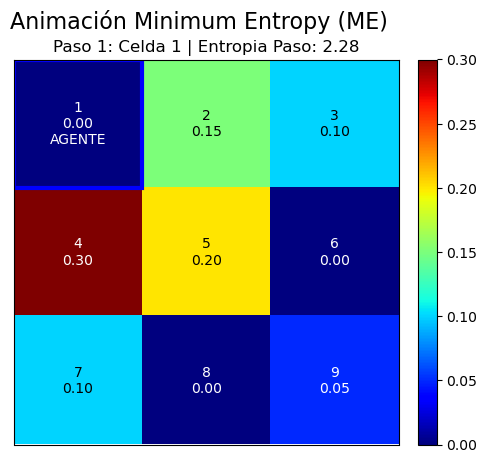

In [1075]:
# === ME ===
df_anim_me = df_me_A  # o df_me_A
bk_series_me = df_anim_me["Bk"]

fig_me, ax_me = plt.subplots(figsize=(6, 5))
fig_me.suptitle("Animación Minimum Entropy (ME)", fontsize=16)
im_me = ax_me.imshow(bk_series_me.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_me.colorbar(im_me, ax=ax_me, fraction=0.046, pad=0.04)
title_me = ax_me.set_title("")
text_objects_me = []
border_me = None

anim_func_me = animation_1_Trajectory(df_anim_me, ax_me, im_me, title_me, text_objects_me, border_me, matriz)
ani_me = FuncAnimation(fig_me, anim_func_me, frames=len(df_anim_me), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_me.to_html5_video())

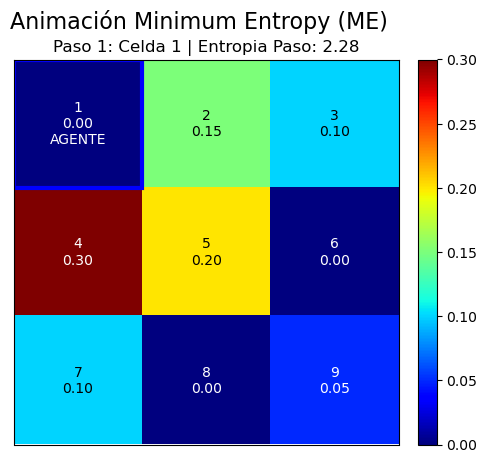

In [1076]:
# === ME ===
df_anim_me = df_me_B  # o df_me_A
bk_series_me = df_anim_me["Bk"]

fig_me, ax_me = plt.subplots(figsize=(6, 5))
fig_me.suptitle("Animación Minimum Entropy (ME)", fontsize=16)
im_me = ax_me.imshow(bk_series_me.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_me.colorbar(im_me, ax=ax_me, fraction=0.046, pad=0.04)
title_me = ax_me.set_title("")
text_objects_me = []
border_me = None

anim_func_me = animation_1_Trajectory(df_anim_me, ax_me, im_me, title_me, text_objects_me, border_me, matriz)
ani_me = FuncAnimation(fig_me, anim_func_me, frames=len(df_anim_me), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_me.to_html5_video())

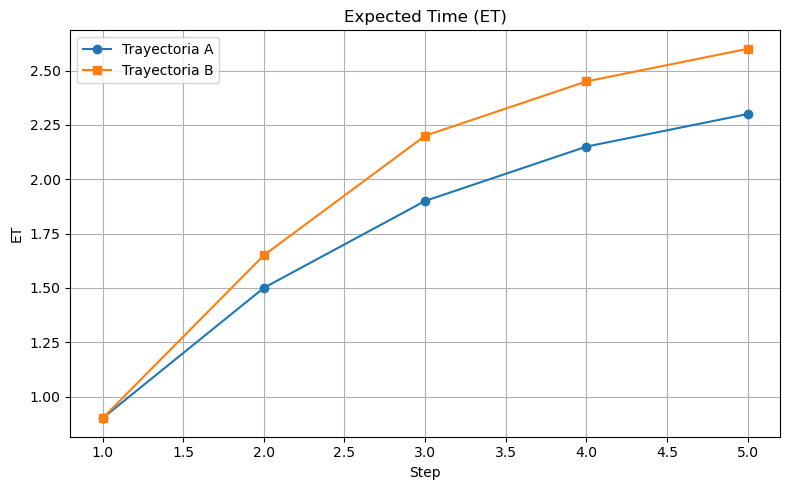

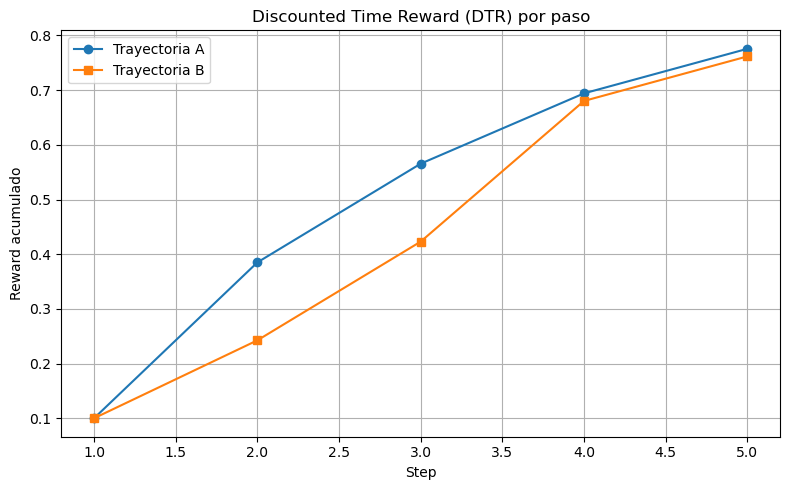

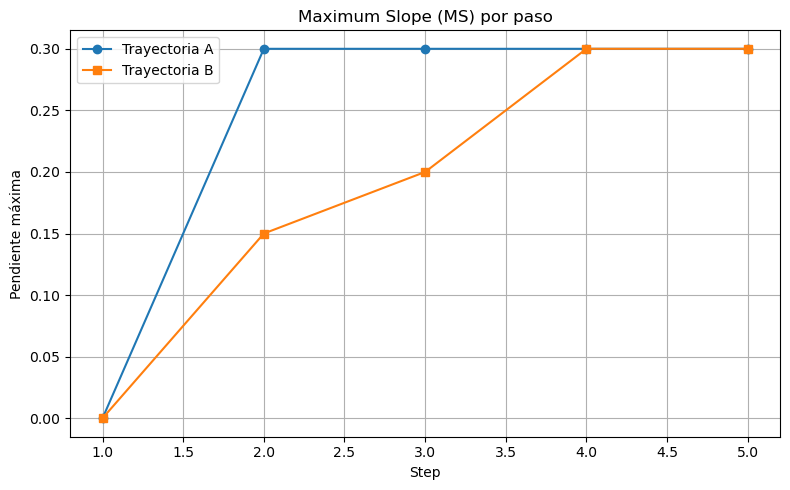

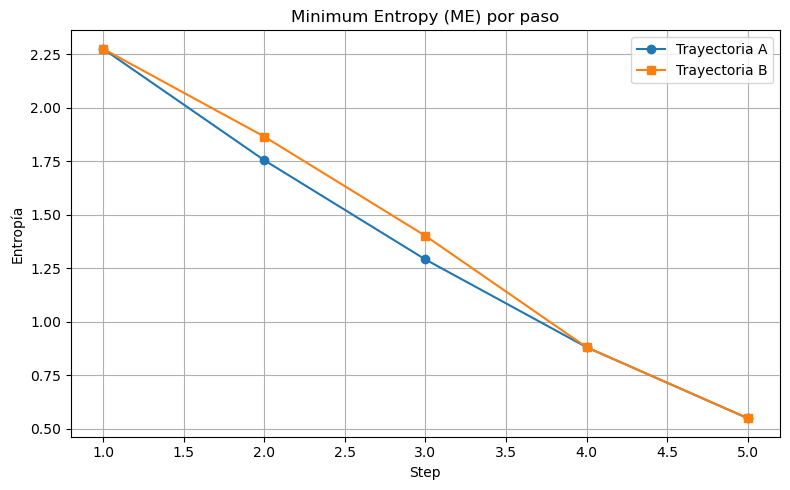

In [1077]:
def graficar_metricas(df_A, df_B, columna, ylabel, titulo, etiqueta_A='Trayectoria A', etiqueta_B='Trayectoria B'):
    pasos_A = range(1, len(df_A) + 1)
    pasos_B = range(1, len(df_B) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(pasos_A, df_A[columna], marker='o', label=etiqueta_A)
    plt.plot(pasos_B, df_B[columna], marker='s', label=etiqueta_B)
    plt.xlabel("Step")
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==== Gráficas ====
# ET acumulado
graficar_metricas(df_et_A, df_et_B,
                  columna="Expected Time acumulado",
                  ylabel="ET",
                  titulo="Expected Time (ET)")

# DTR acumulado
graficar_metricas(df_dtr_A, df_dtr_B,
                  columna="DTR acumulado",
                  ylabel="Reward acumulado",
                  titulo="Discounted Time Reward (DTR) por paso")

# Pendiente máxima en cada paso
graficar_metricas(df_ms_A, df_ms_B,
                  columna="Max Slope",
                  ylabel="Pendiente máxima",
                  titulo="Maximum Slope (MS) por paso")

# Entropía en cada paso
graficar_metricas(df_me_A, df_me_B,
                  columna="Entropia Paso",
                  ylabel="Entropía",
                  titulo="Minimum Entropy (ME) por paso")

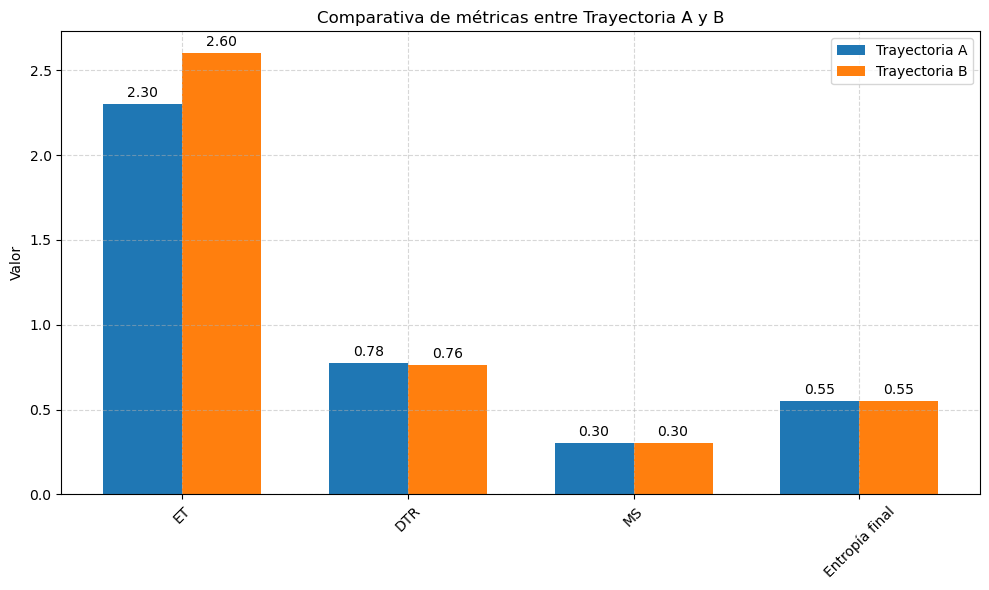

In [1078]:
# Cálculo de todas las métricas
metrics = {
    "Trayectoria A": {
        "ET": et_total_A,
        "DTR": dtr_total_A,
        "MS": ms_A,
        "Entropía final": me_A,
    },
    "Trayectoria B": {
        "ET": et_total_B,
        "DTR": dtr_total_B,
        "MS": ms_B,
        "Entropía final": me_B,
    }
}

# Preparar datos para gráfica
metricas = list(metrics["Trayectoria A"].keys())
valores_A = [metrics["Trayectoria A"][m] for m in metricas]
valores_B = [metrics["Trayectoria B"][m] for m in metricas]

x = np.arange(len(metricas))
width = 0.35  # ancho de barras

# Crear gráfico
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, valores_A, width, label='Trayectoria A', color='tab:blue')
bars2 = ax.bar(x + width/2, valores_B, width, label='Trayectoria B', color='tab:orange')

# Estética
ax.set_ylabel('Valor')
ax.set_title('Comparativa de métricas entre Trayectoria A y B')
ax.set_xticks(x)
ax.set_xticklabels(metricas, rotation=45)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

# Etiquetas en cada barra
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Filtro Bayesiano Recursivo (RBF)

El **Filtro Bayesiano Recursivo (RBF)** es una técnica probabilística para estimar la localización dinámica de un objetivo en entornos inciertos, integrando creencias previas con observaciones sensoriales actuales.

## Notación

- $b(\nu_t)$: Creencia posterior sobre la localización del objetivo en el tiempo $t$.
- $\hat{b}(\nu_t)$: Predicción de la creencia en $t$ antes de observar.
- $P(\nu_t | \nu_{t-1})$: Modelo de transición del objetivo.
- $P(z_t^u | \nu_t, s_t^u)$: Modelo del sensor del agente $u$.
- $\nu_t$: Posición del objetivo en el instante $t$.
- $s_t^u$: Posición del agente $u$ en el instante $t$.
- $\mathcal{G}_\Omega$: Espacio discreto de búsqueda.

---

## Fase de Predicción

Se estima la creencia futura del objetivo usando su modelo de transición:

$$
\hat{b}(\nu_t) = \sum_{\nu_{t-1} \in \mathcal{G}_\Omega} P(\nu_t | \nu_{t-1}) \cdot b(\nu_{t-1})
\tag{3.8}
$$

---

## Fase de Actualización

Se refina la predicción incorporando observaciones de los agentes:

$$
b(\nu_t) = \frac{1}{\xi} \prod_{u=1}^{U} P(z_t^u | \nu_t, s_t^u) \cdot \hat{b}(\nu_t)
\tag{3.9}
$$

donde $\xi$ es un factor de normalización:

$$
\xi = \sum_{\nu_t \in \mathcal{G}_\Omega} \left( \prod_{u=1}^{U} P(z_t^u | \nu_t, s_t^u) \cdot \hat{b}(\nu_t) \right)
$$

---

## Pseudocódigo del algoritmo RBF

$$
\begin{array}{l}
\textbf{Entrada: } b_{k-1}(\nu),\ s_k,\ z_k,\ P(\nu|\nu'),\ d_{\text{max}},\ pd_{\text{max}},\ \sigma \\
\textbf{Inicialización: } b_k(\nu) \gets 0 \\
\\
\textbf{Predicción: } \hat{b}_k(\nu) = \sum_{\nu'} P(\nu|\nu') \cdot b_{k-1}(\nu') \\
\textbf{Actualización: } b_k(\nu) = \prod_{u=1}^U P(z_k^u|\nu, s_k^u) \cdot \hat{b}_k(\nu) \\
\textbf{Normalización: } b_k(\nu) \gets \frac{b_k(\nu)}{\sum_{\nu} b_k(\nu)} \\
\textbf{Salida: } b_k(\nu)
\end{array}
$$



# Algoritmos tradicionales (voraz) adaptados a trayectorias discretas para minimizar/maximizar estas funciones objetivo

In [1079]:
# Función auxiliar para convertir trayectoria a 1D (1-based)
def convertir_trayectoria_1D(trayectoria, n_cols):
    return [i*n_cols + j + 1 for i,j in trayectoria]

def greedy_search_ET(
    matriz_inicial, pos_inicial, pasos_maximos=5,
    actualizar=False, movimientos=None,
    modo_actualizacion='simple',
    parametros_rbf=None):

    if movimientos is None:
        movimiento = [[0, -1], [-1,0], [1,0], [0,1]]  # omito [0,0] para no quedarse en el mismo lugar
    else:
        movimiento = movimientos

    bk = matriz_inicial.copy()
    expected_time = 0
    data = []
    trayectoria = []
    rows, cols = bk.shape

    i, j = pos_inicial

    for paso_num in range(pasos_maximos):
        trayectoria.append((i,j))

        # Calcular ET del paso
        et_paso = ET_step(bk, (i,j))
        expected_time += et_paso

        idx_celda = i*cols + j + 1
        data.append({
            "Paso": paso_num,
            "Celda Índice": idx_celda,
            "Valor Celda": matriz_inicial[i,j],
            "Expected Time del paso": et_paso,
            "Expected Time acumulado": expected_time,
            "Bk": bk.copy()
        })

        # Actualizar mapa de probabilidades
        pos_flat = i*cols + j
        if actualizar:
            if modo_actualizacion=='simple':
                bk = update_probabilities(bk, pos_flat)
            elif modo_actualizacion=='rbf' and parametros_rbf is not None:
                pdmax = min(parametros_rbf.get('pdmax',1), 0.9999)
                bk = update_probabilitiesRBF(
                    bk,
                    pos_flat,
                    pos_obj=parametros_rbf['pos_obj'],
                    p_transicion=parametros_rbf['p_transicion'],
                    dmax=parametros_rbf['dmax'],
                    pdmax=pdmax,
                    sigma=parametros_rbf['sigma']
                )
        else:
            bk[i,j] = 0

        max_val = -np.inf
        siguiente = None
        for mov in movimiento:
            ni, nj = i + mov[0], j + mov[1]
            if 0 <= ni < rows and 0 <= nj < cols:
                if bk[ni,nj] > max_val:
                    max_val = bk[ni,nj]
                    siguiente = (ni, nj)

        if siguiente is None:
            break

        i, j = siguiente

    trayectoria_1D = convertir_trayectoria_1D(trayectoria, cols)
    return pd.DataFrame(data), expected_time, trayectoria_1D


# ==== Búsqueda Voraz para DTR ====
def greedy_search_DTR(
        matriz_inicial, pos_inicial, pasos_maximos=5, gamma=0.95,
        actualizar=False, movimientos=None, modo_actualizacion='simple',
        parametros_rbf=None):
    
    if movimientos is None:
        movimientos = [[0,-1],[-1,0],[1,0],[0,1]]

    bk = matriz_inicial.copy()
    rows, cols = bk.shape
    dtr_total = 0
    data = []
    trayectoria = []

    i,j = pos_inicial

    for paso_num in range(pasos_maximos):
        trayectoria.append((i,j))

        reward = (gamma ** (paso_num+1)) * bk[i,j]
        dtr_total += reward
        idx_celda = i*cols + j +1
        texto_celda = f"{idx_celda}\n{matriz_inicial[i,j]:.2f}"

        data.append({
            "Paso": paso_num,
            "Celda Índice": idx_celda,
            "Valor Celda": matriz_inicial[i,j],
            "Reward paso": reward,
            "DTR acumulado": dtr_total,
            "Texto celda": texto_celda,
            "Bk": bk.copy()
        })

        pos_flat = i*cols + j
        if actualizar:
            if modo_actualizacion=='simple':
                bk = update_probabilities(bk,pos_flat)
            elif modo_actualizacion=='rbf' and parametros_rbf is not None:
                pdmax = min(parametros_rbf.get('pdmax',1), 0.9999)
                bk = update_probabilitiesRBF(
                    bk,pos_flat,
                    pos_obj=parametros_rbf['pos_obj'],
                    p_transicion=parametros_rbf['p_transicion'],
                    dmax=parametros_rbf['dmax'],
                    pdmax=pdmax,
                    sigma=parametros_rbf['sigma']
                )
        else:
            bk[i,j]=0

        max_val = -np.inf
        siguiente = None
        for mov in movimientos:
            ni,nj = i+mov[0], j+mov[1]
            if 0<=ni<rows and 0<=nj<cols:
                if bk[ni,nj]>max_val:
                    max_val = bk[ni,nj]
                    siguiente = (ni,nj)
        if siguiente is None:
            break
        i,j = siguiente

    trayectoria_1D = convertir_trayectoria_1D(trayectoria, cols)
    return pd.DataFrame(data), dtr_total, trayectoria_1D


def greedy_search_MS(
    matriz_inicial, pos_inicial, pasos_maximos=5,
    actualizar=False, movimientos=None, modo_actualizacion='simple',
    parametros_rbf=None):

    if movimientos is None:
        movimientos = [[0, -1], [-1,0], [1,0], [0,1]]  # solo vecinos 4-direcciones

    bk = matriz_inicial.copy()
    rows, cols = bk.shape
    max_slope_global = -np.inf
    data = []
    trayectoria = []

    i, j = pos_inicial

    for paso_num in range(pasos_maximos):
        trayectoria.append((i,j))

        # --- Actualizar celda primero ---
        if actualizar:
            pos_flat = i*cols + j
            if modo_actualizacion == 'simple':
                bk = update_probabilities(bk, pos_flat)
            elif modo_actualizacion == 'rbf' and parametros_rbf is not None:
                bk = update_probabilitiesRBF(
                    bk, pos_flat,
                    pos_obj=parametros_rbf['pos_obj'],
                    p_transicion=parametros_rbf['p_transicion'],
                    dmax=parametros_rbf['dmax'],
                    pdmax=parametros_rbf['pdmax'],
                    sigma=parametros_rbf['sigma']
                )
        else:
            bk[i,j] = 0  # si no se usa actualización

        # --- Valor de la celda ya visitada ---
        valor_actual = bk[i,j]

        # --- Calcular Max Slope solo con vecinos ---
        max_slope_local = -np.inf
        for mov in movimientos:
            ni, nj = i + mov[0], j + mov[1]
            if 0 <= ni < rows and 0 <= nj < cols:
                slope_cand = bk[ni,nj] - valor_actual  # diferencia con valor actualizado
                if slope_cand > max_slope_local:
                    max_slope_local = slope_cand

        if max_slope_local > max_slope_global:
            max_slope_global = max_slope_local

        idx_celda = i*cols + j + 1
        data.append({
            "Paso": paso_num,
            "Celda Índice": idx_celda,
            "Valor Celda": valor_actual,
            "Max Slope hasta ahora": max_slope_global,
            "Bk": bk.copy()
        })

        # --- Elegir siguiente movimiento (máxima pendiente local) ---
        siguiente = None
        mejor_slope_mov = -np.inf
        for mov in movimientos:
            ni, nj = i + mov[0], j + mov[1]
            if 0 <= ni < rows and 0 <= nj < cols:
                slope_mov = bk[ni,nj] - valor_actual
                if slope_mov > mejor_slope_mov:
                    mejor_slope_mov = slope_mov
                    siguiente = (ni,nj)

        if siguiente is None:
            break

        i, j = siguiente

    trayectoria_1D = convertir_trayectoria_1D(trayectoria, cols)
    return pd.DataFrame(data), max_slope_global, trayectoria_1D


# ==== Búsqueda Voraz para ME ====
def greedy_search_ME(
        matriz_inicial, pos_inicial, pasos_maximos=5,
        actualizar=False, movimientos=None, modo_actualizacion='simple',
        parametros_rbf=None):

    if movimientos is None:
        movimientos = [[0, -1], [-1,0],[0,0],[1,0],[0,1]]

    bk = matriz_inicial.copy()
    mapa_actual = bk.copy()
    rows,cols = mapa_actual.shape
    data=[]
    trayectoria=[]

    i,j=pos_inicial
    entropia_inicial = entropy(mapa_actual)

    for paso_num in range(pasos_maximos):
        trayectoria.append((i,j))
        pos_flat = i*cols + j

        if actualizar:
            if modo_actualizacion=='simple':
                mapa_actual = update_probabilities(mapa_actual,pos_flat)
            elif modo_actualizacion=='rbf' and parametros_rbf is not None:
                mapa_actual = update_probabilitiesRBF(
                    mapa_actual,pos_flat,
                    pos_obj=parametros_rbf['pos_obj'],
                    p_transicion=parametros_rbf['p_transicion'],
                    dmax=parametros_rbf['dmax'],
                    pdmax=parametros_rbf['pdmax'],
                    sigma=parametros_rbf['sigma']
                )
        else:
            mapa_actual[i,j]=0

        idx_celda = i*cols + j +1
        entropia_actual = entropy(mapa_actual)
        data.append({
            "Paso": paso_num,
            "Celda Índice": idx_celda,
            "Valor Celda": bk[i,j],
            "Entropía paso": entropia_actual,
            "Bk": mapa_actual.copy()
        })

        mejor_entropia = np.inf
        siguiente=None
        for mov in movimientos:
            ni,nj = i+mov[0], j+mov[1]
            if 0<=ni<rows and 0<=nj<cols:
                mapa_temp = mapa_actual.copy()
                if actualizar:
                    if modo_actualizacion=='simple':
                        mapa_temp = update_probabilities(mapa_temp,ni*cols+nj)
                    elif modo_actualizacion=='rbf' and parametros_rbf is not None:
                        mapa_temp = update_probabilitiesRBF(
                            mapa_temp,ni*cols+nj,
                            pos_obj=parametros_rbf['pos_obj'],
                            p_transicion=parametros_rbf['p_transicion'],
                            dmax=parametros_rbf['dmax'],
                            pdmax=parametros_rbf['pdmax'],
                            sigma=parametros_rbf['sigma']
                        )
                else:
                    mapa_temp[ni,nj]=0

                entropia = entropy(mapa_temp)
                if entropia < mejor_entropia:
                    mejor_entropia = entropia
                    siguiente = (ni,nj)

        if siguiente is None:
            break
        i,j = siguiente

    entropia_final = entropy(mapa_actual)
    trayectoria_1D = convertir_trayectoria_1D(trayectoria, cols)
    return pd.DataFrame(data), {"Entropía inicial":entropia_inicial,"Entropía final":entropia_final}, trayectoria_1D


## Búsqueda voraz sin actualización de mapa

In [1080]:
# ==== MATRIZ BASE ====
matriz = np.array([
    [0.10, 0.15, 0.10],
    [0.30, 0.20, 0.00],
    [0.10, 0.00, 0.05]
])

# Cuatro direcciones cardinales (sin quedarse en la misma celda)
movimientos = [[0,-1], [-1,0], [1,0], [0,1]]

# ==== CONFIGURACIÓN ====
pos_inicial = (0, 0)  # Empezamos en la celda 0.10
pasos_max = 5

# ==== Ejecutar búsqueda voraz para ET ====
et_df_greedy, et_greedy_total, et_trayectoria_1D = greedy_search_ET(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    movimientos=movimientos,
    actualizar=False,
    modo_actualizacion='simple'
)
print("ET Total Greedy:", round(et_greedy_total, 4))
print("Trayectoria ET:", et_trayectoria_1D)

# ==== Ejecutar búsqueda voraz para DTR ====
dtr_df_greedy, dtr_greedy_total, dtr_trayectoria_1D = greedy_search_DTR(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    gamma=0.95,
    movimientos=movimientos,
    actualizar=False,
    modo_actualizacion='simple'
)
print("\nDTR Total Greedy:", round(dtr_greedy_total, 4))
print("Trayectoria DTR:", dtr_trayectoria_1D)

# ==== Ejecutar búsqueda voraz para MS ====
ms_df_greedy, ms_greedy_total, ms_trayectoria_1D = greedy_search_MS(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    movimientos=movimientos,
    actualizar=False,
    modo_actualizacion='simple'
)
print("\nMS Total Greedy:", round(ms_greedy_total, 4))
print("Trayectoria MS:", ms_trayectoria_1D)

# ==== Ejecutar búsqueda voraz para ME ====
me_df_greedy, me_entropy_dict, me_trayectoria_1D = greedy_search_ME(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    movimientos=movimientos,
    actualizar=False,
    modo_actualizacion='simple'
)
print("\nEntropía Inicial:", round(me_entropy_dict["Entropía inicial"], 4))
print("Entropía Final Greedy (ME):", round(me_entropy_dict["Entropía final"], 4))
print("Trayectoria ME:", me_trayectoria_1D)


ET Total Greedy: 2.3
Trayectoria ET: [1, 4, 5, 2, 3]

DTR Total Greedy: 0.7368
Trayectoria DTR: [1, 4, 5, 2, 3]

MS Total Greedy: 0.3
Trayectoria MS: [1, 4, 5, 2, 3]

Entropía Inicial: 2.6087
Entropía Final Greedy (ME): 0.5483
Trayectoria ME: [1, 4, 5, 2, 3]


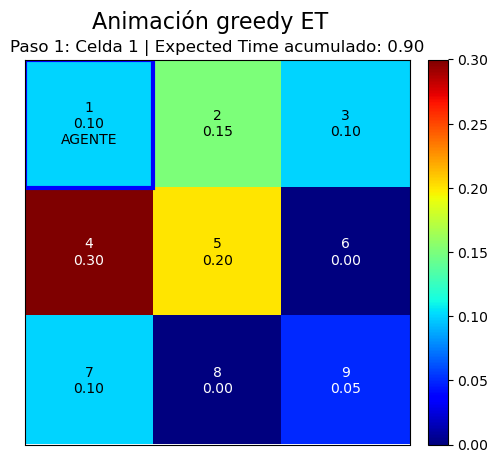

In [1081]:
# === ET ===
df_anim_et = et_df_greedy
bk_series_et = df_anim_et["Bk"]

fig_et, ax_et = plt.subplots(figsize=(6, 5))
fig_et.suptitle("Animación greedy ET", fontsize=16)
im_et = ax_et.imshow(bk_series_et.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_et.colorbar(im_et, ax=ax_et, fraction=0.046, pad=0.04)
title_et = ax_et.set_title("")
text_objects_et = []
border_et = None

anim_func_et = animation_1_Trajectory(df_anim_et, ax_et, im_et, title_et, text_objects_et, border_et, matriz)
ani_et = FuncAnimation(fig_et, anim_func_et, frames=len(df_anim_et), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_et.to_html5_video())

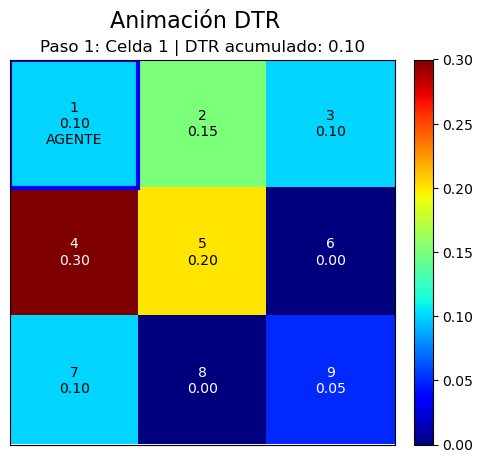

In [1082]:
# === DTR ===
df_anim_dtr = dtr_df_greedy
bk_series_dtr = df_anim_dtr["Bk"]

fig_dtr, ax_dtr = plt.subplots(figsize=(6, 5))
fig_dtr.suptitle("Animación DTR", fontsize=16)
im_dtr = ax_dtr.imshow(bk_series_dtr.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_dtr.colorbar(im_dtr, ax=ax_dtr, fraction=0.046, pad=0.04)
title_dtr = ax_dtr.set_title("")
text_objects_dtr = []
border_dtr = None

anim_func_dtr = animation_1_Trajectory(df_anim_dtr, ax_dtr, im_dtr, title_dtr, text_objects_dtr, border_dtr, matriz)
ani_dtr = FuncAnimation(fig_dtr, anim_func_dtr, frames=len(df_anim_dtr), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_dtr.to_html5_video())

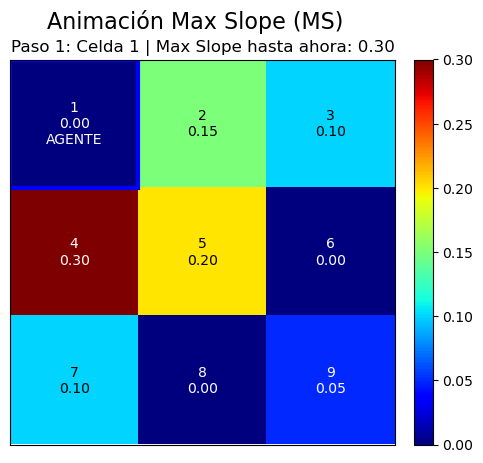

In [1083]:
# === MS ===
df_anim_ms = ms_df_greedy
bk_series_ms = df_anim_ms["Bk"]

fig_ms, ax_ms = plt.subplots(figsize=(6, 5))
fig_ms.suptitle("Animación Max Slope (MS)", fontsize=16)
im_ms = ax_ms.imshow(bk_series_ms.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_ms.colorbar(im_ms, ax=ax_ms, fraction=0.046, pad=0.04)
title_ms = ax_ms.set_title("")
text_objects_ms = []
border_ms = None

anim_func_ms = animation_1_Trajectory(df_anim_ms, ax_ms, im_ms, title_ms, text_objects_ms, border_ms, matriz)
ani_ms = FuncAnimation(fig_ms, anim_func_ms, frames=len(df_anim_ms), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_ms.to_html5_video())

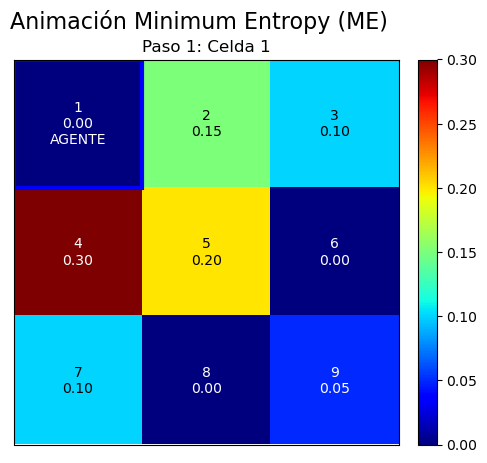

In [1084]:
# === ME ===
df_anim_me = me_df_greedy
bk_series_me = df_anim_me["Bk"]

fig_me, ax_me = plt.subplots(figsize=(6, 5))
fig_me.suptitle("Animación Minimum Entropy (ME)", fontsize=16)
im_me = ax_me.imshow(bk_series_me.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_me.colorbar(im_me, ax=ax_me, fraction=0.046, pad=0.04)
title_me = ax_me.set_title("")
text_objects_me = []
border_me = None

anim_func_me = animation_1_Trajectory(df_anim_me, ax_me, im_me, title_me, text_objects_me, border_me, matriz)
ani_me = FuncAnimation(fig_me, anim_func_me, frames=len(df_anim_me), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_me.to_html5_video())

## Busqueda Voraz Actualización del mapa Ideal

In [1085]:
# ==== MATRIZ BASE ====
matriz = np.array([
    [0.10, 0.15, 0.10],
    [0.30, 0.20, 0.00],
    [0.10, 0.00, 0.05]
])

# Cuatro direcciones cardinales y una de no moverse
movimiento = [[0, -1], [-1,0], [0,0], [1,0], [0,1]]

# ==== Configuración ====
pos_inicial = (0, 0)  # Empezamos donde 0.10
pasos_max = 5

# ==== Ejecutar búsqueda voraz para ET ====
et_df_greedy_simple, et_greedy_total_simple, et_trayectoria = greedy_search_ET(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    movimientos=movimiento,
    actualizar=True,
    modo_actualizacion='simple'
)
print("\nET Total Greedy:", et_greedy_total_simple)
print("Trayectoria ET:", et_trayectoria)

# ==== Ejecutar búsqueda voraz para DTR ====
dtr_df_greedy_simple, dtr_greedy_total_simple, dtr_trayectoria = greedy_search_DTR(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    gamma=0.95,
    movimientos=movimiento,
    actualizar=True,
    modo_actualizacion='simple'
)
print("\nDTR Total Greedy:", dtr_greedy_total_simple)
print("Trayectoria DTR:", dtr_trayectoria)

# ==== Ejecutar búsqueda voraz para MS ====
ms_df_greedy_simple, ms_greedy_total_simple, ms_trayectoria = greedy_search_MS(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    movimientos=movimiento,
    actualizar=True,
    modo_actualizacion='simple'
)
print("\nMS Total Greedy:", ms_greedy_total_simple)
print("Trayectoria MS:", ms_trayectoria)

# ==== Ejecutar búsqueda voraz para ME ====
me_df_greedy_simple, me_entropy_simple, me_trayectoria = greedy_search_ME(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    movimientos=movimiento,
    actualizar=True,
    modo_actualizacion='simple'
)
print("\nEntropía Inicial:", me_entropy_simple["Entropía inicial"])
print("Entropía Final Greedy (ME):", me_entropy_simple["Entropía final"])
print("Trayectoria ME:", me_trayectoria)



ET Total Greedy: 3.4583333333333335
Trayectoria ET: [1, 4, 5, 2, 3]

DTR Total Greedy: 1.2965772187499998
Trayectoria DTR: [1, 4, 5, 2, 3]

MS Total Greedy: 0.4
Trayectoria MS: [1, 4, 5, 2, 3]

Entropía Inicial: 2.608694969562842
Entropía Final Greedy (ME): 0.9182958340544896
Trayectoria ME: [1, 2, 5, 4, 7]


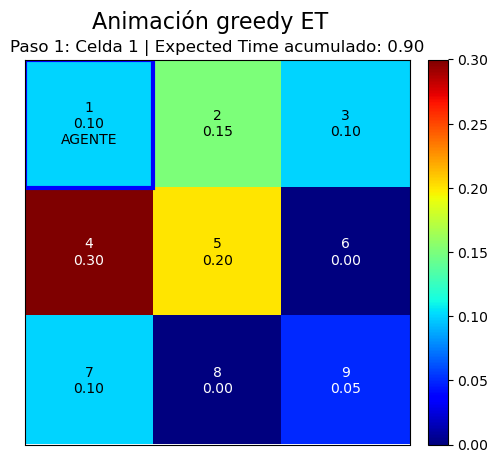

In [1086]:
# === ET ===
df_anim_et = et_df_greedy_simple
bk_series_et = df_anim_et["Bk"]

fig_et, ax_et = plt.subplots(figsize=(6, 5))
fig_et.suptitle("Animación greedy ET", fontsize=16)
im_et = ax_et.imshow(bk_series_et.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_et.colorbar(im_et, ax=ax_et, fraction=0.046, pad=0.04)
title_et = ax_et.set_title("")
text_objects_et = []
border_et = None

anim_func_et = animation_1_Trajectory(df_anim_et, ax_et, im_et, title_et, text_objects_et, border_et, matriz)
ani_et = FuncAnimation(fig_et, anim_func_et, frames=len(df_anim_et), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_et.to_html5_video())

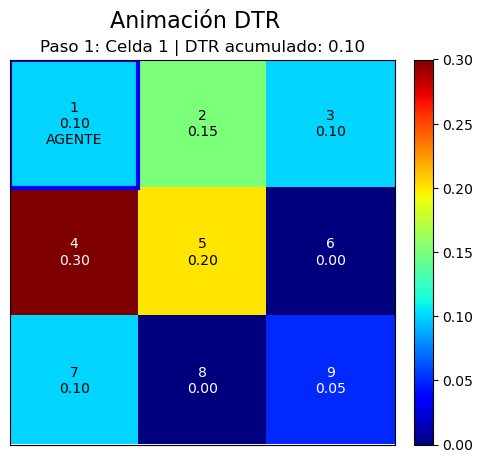

In [1087]:
# === DTR ===
df_anim_dtr = dtr_df_greedy_simple
bk_series_dtr = df_anim_dtr["Bk"]

fig_dtr, ax_dtr = plt.subplots(figsize=(6, 5))
fig_dtr.suptitle("Animación DTR", fontsize=16)
im_dtr = ax_dtr.imshow(bk_series_dtr.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_dtr.colorbar(im_dtr, ax=ax_dtr, fraction=0.046, pad=0.04)
title_dtr = ax_dtr.set_title("")
text_objects_dtr = []
border_dtr = None

anim_func_dtr = animation_1_Trajectory(df_anim_dtr, ax_dtr, im_dtr, title_dtr, text_objects_dtr, border_dtr, matriz)
ani_dtr = FuncAnimation(fig_dtr, anim_func_dtr, frames=len(df_anim_dtr), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_dtr.to_html5_video())

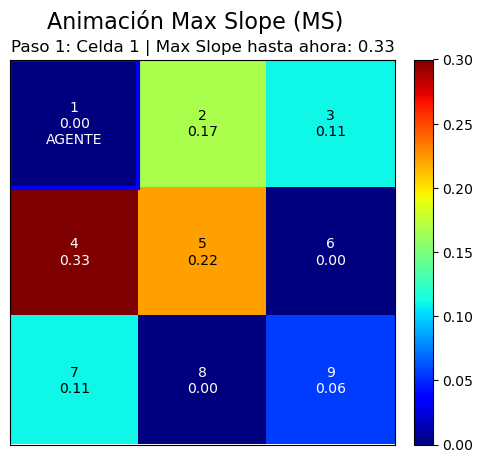

In [1088]:
# === MS ===
df_anim_ms = ms_df_greedy_simple
bk_series_ms = df_anim_ms["Bk"]

fig_ms, ax_ms = plt.subplots(figsize=(6, 5))
fig_ms.suptitle("Animación Max Slope (MS)", fontsize=16)
im_ms = ax_ms.imshow(bk_series_ms.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_ms.colorbar(im_ms, ax=ax_ms, fraction=0.046, pad=0.04)
title_ms = ax_ms.set_title("")
text_objects_ms = []
border_ms = None

anim_func_ms = animation_1_Trajectory(df_anim_ms, ax_ms, im_ms, title_ms, text_objects_ms, border_ms, matriz)
ani_ms = FuncAnimation(fig_ms, anim_func_ms, frames=len(df_anim_ms), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_ms.to_html5_video())

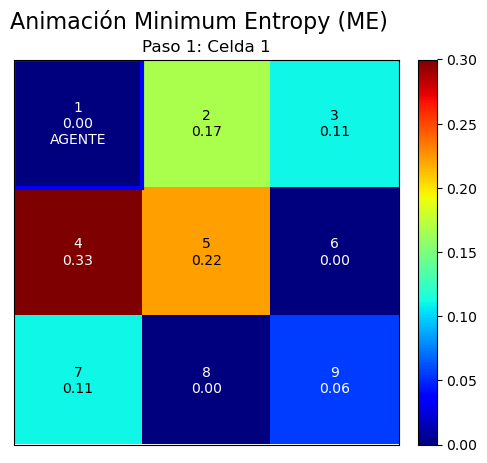

In [1089]:
# === ME ===
df_anim_me = me_df_greedy_simple
bk_series_me = df_anim_me["Bk"]

fig_me, ax_me = plt.subplots(figsize=(6, 5))
fig_me.suptitle("Animación Minimum Entropy (ME)", fontsize=16)
im_me = ax_me.imshow(bk_series_me.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_me.colorbar(im_me, ax=ax_me, fraction=0.046, pad=0.04)
title_me = ax_me.set_title("")
text_objects_me = []
border_me = None

anim_func_me = animation_1_Trajectory(df_anim_me, ax_me, im_me, title_me, text_objects_me, border_me, matriz)
ani_me = FuncAnimation(fig_me, anim_func_me, frames=len(df_anim_me), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_me.to_html5_video())

## Búsqueda voraz con actualización de mapa con RBF (pdmax = 1)
La actualización de este mapa se realiza mediante un filtro recursivo bayesiano (RBF) con parámetros del sensor definidos mediante una distribución gaussiana. Además se considera que el indicio utilizado es estático. Esto se realiza mediante una matriz de probabilidad de transición.

In [1090]:
# Parámetros de sensor para RBF:
parametros_RBF = {
    "pos_obj": (0,0),  # Inicializar el objetivo en la misma posición que el agente
    "p_transicion": np.array([
        [0, 0, 0],
        [0,  1, 0],
        [0, 0, 0]
    ]),
    "dmax": 1,       # Distancia máxima de detección
    "pdmax": 1,      # Probabilidad máxima de detección
    "sigma": 100     # Sensibilidad a la distancia
}

# ==== Ejecutar búsqueda voraz para ET ====
et_df_greedy_rbf1, et_greedy_total_rbf1, et_trayectoria_rbf1 = greedy_search_ET(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    movimientos=movimiento,
    actualizar=True,
    modo_actualizacion='rbf',
    parametros_rbf=parametros_RBF
)
print("\nET Total Greedy:", et_greedy_total_rbf1)
print("Trayectoria ET:", et_trayectoria_rbf1)

# ==== Ejecutar búsqueda voraz para DTR ====
dtr_df_greedy_rbf1, dtr_greedy_total_rbf1, dtr_trayectoria_rbf1 = greedy_search_DTR(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    gamma=0.95,
    movimientos=movimiento,
    actualizar=True,
    modo_actualizacion='rbf',
    parametros_rbf=parametros_RBF
)
print("\nDTR Total Greedy:", dtr_greedy_total_rbf1)
print("Trayectoria DTR:", dtr_trayectoria_rbf1)

# ==== Ejecutar búsqueda voraz para MS ====
ms_df_greedy_rbf1, ms_greedy_total_rbf1, ms_trayectoria_rbf1 = greedy_search_MS(
    matriz_inicial=matriz,
    pos_inicial=pos_inicial,
    pasos_maximos=pasos_max,
    movimientos=movimiento,
    actualizar=True,
    modo_actualizacion='rbf',
    parametros_rbf=parametros_RBF
)
print("\nMS Total Greedy:", ms_greedy_total_rbf1)
print("Trayectoria MS:", ms_trayectoria_rbf1)

# ==== Ejecutar búsqueda voraz para ME ====
me_df_greedy_rbf1, me_entropy_rbf1, me_trayectoria_rbf1 = greedy_search_ME(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    movimientos=movimiento,
    actualizar=True,
    modo_actualizacion='rbf',
    parametros_rbf=parametros_RBF
)
print("\nEntropía Inicial:", me_entropy_rbf1["Entropía inicial"])
print("Entropía Final Greedy (ME):", me_entropy_rbf1["Entropía final"])
print("Trayectoria ME:", me_trayectoria_rbf1)


ET Total Greedy: 3.4585354633112866
Trayectoria ET: [1, 4, 5, 2, 3]

DTR Total Greedy: 1.2964161897169322
Trayectoria DTR: [1, 4, 5, 2, 3]

MS Total Greedy: 0.4
Trayectoria MS: [1, 4, 5, 2, 3]

Entropía Inicial: 2.608694969562842
Entropía Final Greedy (ME): 0.9182958340544896
Trayectoria ME: [1, 2, 5, 4, 7]


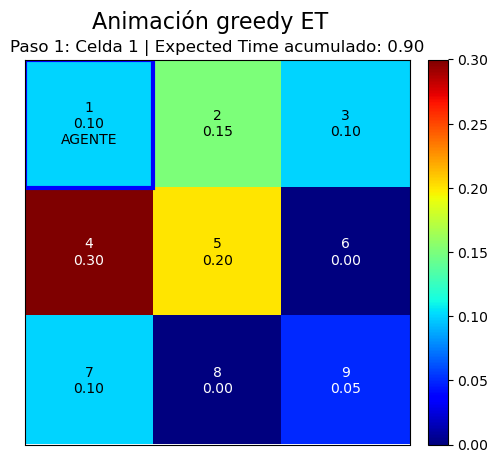

In [1091]:
# === ET ===
df_anim_et = et_df_greedy_rbf1
bk_series_et = df_anim_et["Bk"]

fig_et, ax_et = plt.subplots(figsize=(6, 5))
fig_et.suptitle("Animación greedy ET", fontsize=16)
im_et = ax_et.imshow(bk_series_et.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_et.colorbar(im_et, ax=ax_et, fraction=0.046, pad=0.04)
title_et = ax_et.set_title("")
text_objects_et = []
border_et = None

anim_func_et = animation_1_Trajectory(df_anim_et, ax_et, im_et, title_et, text_objects_et, border_et, matriz)
ani_et = FuncAnimation(fig_et, anim_func_et, frames=len(df_anim_et), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_et.to_html5_video())

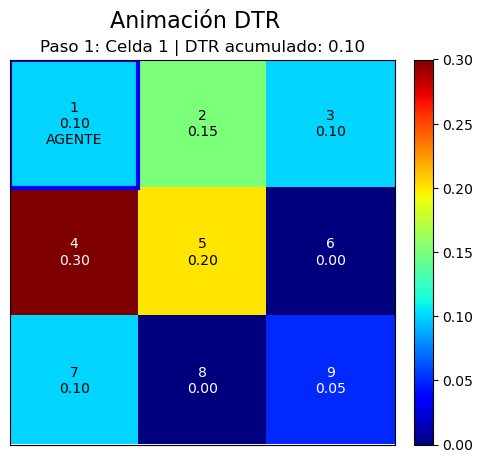

In [1092]:
# === DTR ===
df_anim_dtr = dtr_df_greedy_rbf1
bk_series_dtr = df_anim_dtr["Bk"]

fig_dtr, ax_dtr = plt.subplots(figsize=(6, 5))
fig_dtr.suptitle("Animación DTR", fontsize=16)
im_dtr = ax_dtr.imshow(bk_series_dtr.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_dtr.colorbar(im_dtr, ax=ax_dtr, fraction=0.046, pad=0.04)
title_dtr = ax_dtr.set_title("")
text_objects_dtr = []
border_dtr = None

anim_func_dtr = animation_1_Trajectory(df_anim_dtr, ax_dtr, im_dtr, title_dtr, text_objects_dtr, border_dtr, matriz)
ani_dtr = FuncAnimation(fig_dtr, anim_func_dtr, frames=len(df_anim_dtr), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_dtr.to_html5_video())

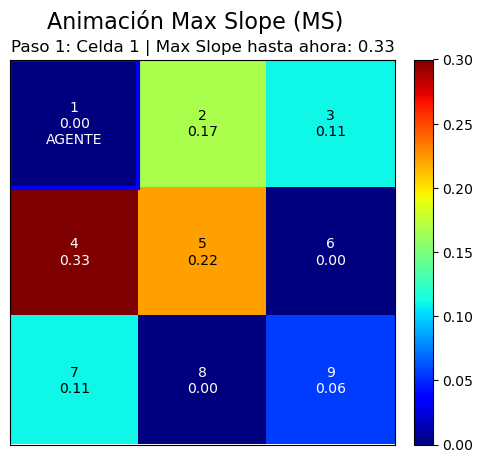

In [1093]:
# === MS ===
df_anim_ms = ms_df_greedy_rbf1
bk_series_ms = df_anim_ms["Bk"]

fig_ms, ax_ms = plt.subplots(figsize=(6, 5))
fig_ms.suptitle("Animación Max Slope (MS)", fontsize=16)
im_ms = ax_ms.imshow(bk_series_ms.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_ms.colorbar(im_ms, ax=ax_ms, fraction=0.046, pad=0.04)
title_ms = ax_ms.set_title("")
text_objects_ms = []
border_ms = None

anim_func_ms = animation_1_Trajectory(df_anim_ms, ax_ms, im_ms, title_ms, text_objects_ms, border_ms, matriz)
ani_ms = FuncAnimation(fig_ms, anim_func_ms, frames=len(df_anim_ms), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_ms.to_html5_video())

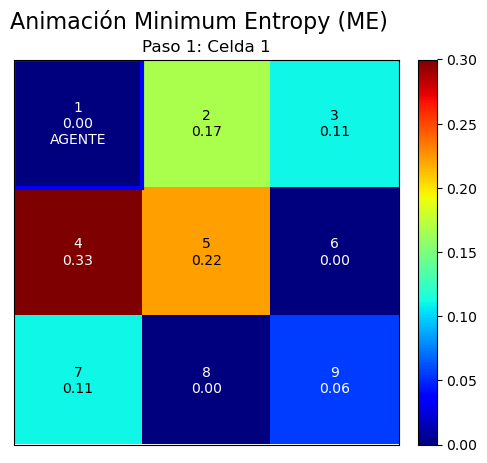

In [1094]:
# === ME ===
df_anim_me = me_df_greedy_rbf1
bk_series_me = df_anim_me["Bk"]

fig_me, ax_me = plt.subplots(figsize=(6, 5))
fig_me.suptitle("Animación Minimum Entropy (ME)", fontsize=16)
im_me = ax_me.imshow(bk_series_me.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_me.colorbar(im_me, ax=ax_me, fraction=0.046, pad=0.04)
title_me = ax_me.set_title("")
text_objects_me = []
border_me = None

anim_func_me = animation_1_Trajectory(df_anim_me, ax_me, im_me, title_me, text_objects_me, border_me, matriz)
ani_me = FuncAnimation(fig_me, anim_func_me, frames=len(df_anim_me), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_me.to_html5_video())

## Búsqueda voraz con actualización de mapa con RBF (pdmax = 0.8)

In [1095]:
# Parámetros de sensor para RBF2:
parametros_RBF2 = {
    "pos_obj": (0,0),  # Inicializar el objetivo en la misma posición que el agente
    "p_transicion": np.array([
        [0, 0, 0],
        [0,  1, 0],
        [0, 0, 0]
    ]),
    "dmax": 1,       # Distancia máxima de detección
    "pdmax": 0.8,    # Probabilidad máxima de detección
    "sigma": 100     # Sensibilidad a la distancia
}

# ==== Ejecutar búsqueda voraz para ET ====
et_df_greedy_rbf2, et_greedy_total_rbf2, et_trayectoria_rbf2 = greedy_search_ET(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    movimientos=movimiento,
    actualizar=True,
    modo_actualizacion='rbf',
    parametros_rbf=parametros_RBF2
)
print("\nET Total Greedy:", et_greedy_total_rbf2)
print("Trayectoria ET:", et_trayectoria_rbf2)

# ==== Ejecutar búsqueda voraz para DTR ====
dtr_df_greedy_rbf2, dtr_greedy_total_rbf2, dtr_trayectoria_rbf2 = greedy_search_DTR(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    gamma=0.95,
    movimientos=movimiento,
    actualizar=True,
    modo_actualizacion='rbf',
    parametros_rbf=parametros_RBF2
)
print("\nDTR Total Greedy:", dtr_greedy_total_rbf2)
print("Trayectoria DTR:", dtr_trayectoria_rbf2)

# ==== Ejecutar búsqueda voraz para MS ====
ms_df_greedy_rbf2, ms_greedy_total_rbf2, ms_trayectoria_rbf2 = greedy_search_MS(
    matriz_inicial=matriz,
    pos_inicial=pos_inicial,
    pasos_maximos=pasos_max,
    movimientos=movimiento,
    actualizar=True,
    modo_actualizacion='rbf',
    parametros_rbf=parametros_RBF2
)
print("\nMS Total Greedy:", ms_greedy_total_rbf2)
print("Trayectoria MS:", ms_trayectoria_rbf2)

# ==== Ejecutar búsqueda voraz para ME ====
me_df_greedy_rbf2, me_entropy_rbf2, me_trayectoria_rbf2 = greedy_search_ME(
    matriz,
    pos_inicial,
    pasos_maximos=pasos_max,
    movimientos=movimiento,
    actualizar=True,
    modo_actualizacion='rbf',
    parametros_rbf=parametros_RBF2
)
print("\nEntropía Inicial:", me_entropy_rbf2["Entropía inicial"])
print("Entropía Final Greedy (ME):", me_entropy_rbf2["Entropía final"])
print("Trayectoria ME:", me_trayectoria_rbf2)


ET Total Greedy: 3.7413338579578985
Trayectoria ET: [1, 4, 5, 2, 3]

DTR Total Greedy: 1.0698615562444667
Trayectoria DTR: [1, 4, 5, 2, 3]

MS Total Greedy: 0.3043478260869565
Trayectoria MS: [1, 4, 5, 2, 3]

Entropía Inicial: 2.608694969562842
Entropía Final Greedy (ME): 1.9457756490206664
Trayectoria ME: [1, 2, 3, 2, 5]


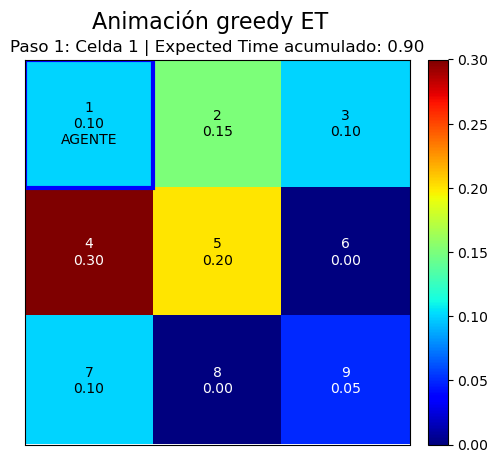

In [1096]:
# === ET ===
df_anim_et = et_df_greedy_rbf2
bk_series_et = df_anim_et["Bk"]

fig_et, ax_et = plt.subplots(figsize=(6, 5))
fig_et.suptitle("Animación greedy ET", fontsize=16)
im_et = ax_et.imshow(bk_series_et.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_et.colorbar(im_et, ax=ax_et, fraction=0.046, pad=0.04)
title_et = ax_et.set_title("")
text_objects_et = []
border_et = None

anim_func_et = animation_1_Trajectory(df_anim_et, ax_et, im_et, title_et, text_objects_et, border_et, matriz)
ani_et = FuncAnimation(fig_et, anim_func_et, frames=len(df_anim_et), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_et.to_html5_video())

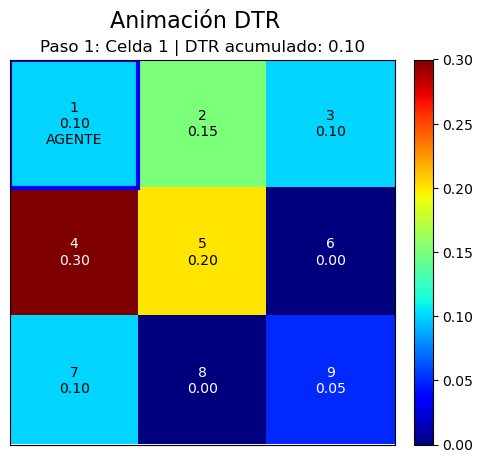

In [1097]:
# === DTR ===
df_anim_dtr = dtr_df_greedy_rbf2
bk_series_dtr = df_anim_dtr["Bk"]

fig_dtr, ax_dtr = plt.subplots(figsize=(6, 5))
fig_dtr.suptitle("Animación DTR", fontsize=16)
im_dtr = ax_dtr.imshow(bk_series_dtr.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_dtr.colorbar(im_dtr, ax=ax_dtr, fraction=0.046, pad=0.04)
title_dtr = ax_dtr.set_title("")
text_objects_dtr = []
border_dtr = None

anim_func_dtr = animation_1_Trajectory(df_anim_dtr, ax_dtr, im_dtr, title_dtr, text_objects_dtr, border_dtr, matriz)
ani_dtr = FuncAnimation(fig_dtr, anim_func_dtr, frames=len(df_anim_dtr), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_dtr.to_html5_video())

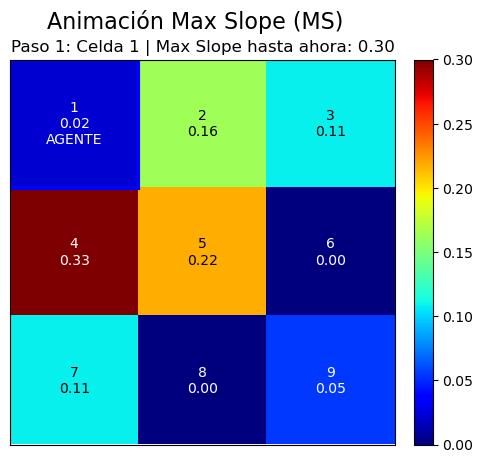

In [1098]:
# === MS ===
df_anim_ms = ms_df_greedy_rbf2
bk_series_ms = df_anim_ms["Bk"]

fig_ms, ax_ms = plt.subplots(figsize=(6, 5))
fig_ms.suptitle("Animación Max Slope (MS)", fontsize=16)
im_ms = ax_ms.imshow(bk_series_ms.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_ms.colorbar(im_ms, ax=ax_ms, fraction=0.046, pad=0.04)
title_ms = ax_ms.set_title("")
text_objects_ms = []
border_ms = None

anim_func_ms = animation_1_Trajectory(df_anim_ms, ax_ms, im_ms, title_ms, text_objects_ms, border_ms, matriz)
ani_ms = FuncAnimation(fig_ms, anim_func_ms, frames=len(df_anim_ms), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_ms.to_html5_video())

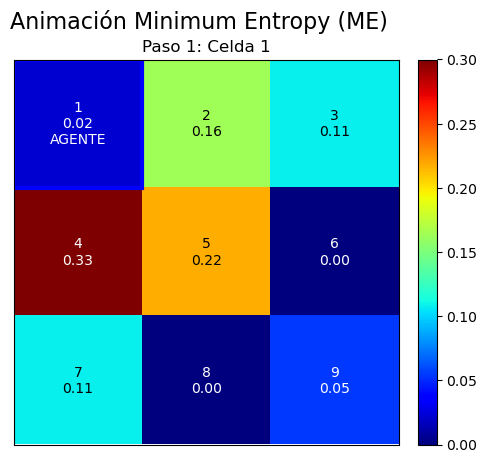

In [1099]:
# === ME ===
df_anim_me = me_df_greedy_rbf2
bk_series_me = df_anim_me["Bk"]

fig_me, ax_me = plt.subplots(figsize=(6, 5))
fig_me.suptitle("Animación Minimum Entropy (ME)", fontsize=16)
im_me = ax_me.imshow(bk_series_me.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_me.colorbar(im_me, ax=ax_me, fraction=0.046, pad=0.04)
title_me = ax_me.set_title("")
text_objects_me = []
border_me = None

anim_func_me = animation_1_Trajectory(df_anim_me, ax_me, im_me, title_me, text_objects_me, border_me, matriz)
ani_me = FuncAnimation(fig_me, anim_func_me, frames=len(df_anim_me), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_me.to_html5_video())


# Funciones objetivo con actualización

# Algoritmos bioinspirados


## Ant Colony Optimization (ACO)

In [1100]:
import numpy as np
import pandas as pd

def ACO(
    func_objetivo,      # La función que se quiere optimizar (minimizar o maximizar). Debe recibir una trayectoria y devolver un valor y datos por paso.
    filas,              # Número de filas del "mapa" o "matriz" sobre el que se mueve la hormiga.
    columnas,           # Número de columnas del mapa.
    nodo_inicial,       # Índice del nodo desde el que comienza cada hormiga.
    movimientos_objetivo,# Lista de movimientos posibles, como [(0,1),(1,0),(-1,0),(0,-1)] para moverse arriba, abajo, izquierda, derecha.
    n_hormigas=10,      # Número de hormigas que se simulan por iteración.
    n_iter=100,         # Número de iteraciones del algoritmo ACO.
    alfa=1.0,           # Exponente de influencia de las feromonas en la probabilidad de escoger un nodo.
    beta=2.0,           # Exponente de influencia de la heurística (en este caso neutra, normalmente distancia u otra medida).
    rho=0.1,            # Tasa de evaporación de feromonas (entre 0 y 1).
    Q=1.0,              # Cantidad de feromona que se deposita en función del valor de la función objetivo.
    modo='min',         # Indica si se busca minimizar ('min') o maximizar ('max') la función objetivo.
    max_pasos=None,     # Número máximo de pasos que puede dar una hormiga en su trayectoria. Si es None, no hay límite.
    valores_celdas=None # (Opcional) Valores asociados a cada celda, por ejemplo para funciones objetivo que dependan de celdas específicas.
):
    nodos = filas * columnas

    def idx_to_xy(idx):
        return idx // columnas, idx % columnas

    def xy_to_idx(x, y):
        return x * columnas + y

    vecinos = [[] for _ in range(nodos)]
    for idx in range(nodos):
        x, y = idx_to_xy(idx)
        for dx, dy in movimientos_objetivo:
            nx, ny = x + dx, y + dy
            if 0 <= nx < filas and 0 <= ny < columnas:
                vecinos[idx].append(xy_to_idx(nx, ny))

    feromonas = np.ones((nodos, nodos))

    mejor_trayectoria = None
    mejor_valor = float('inf') if modo == 'min' else -float('inf')
    mejor_data_pasos = None
    historial_valores = []

    nombre_obj = func_objetivo.__name__.upper()
    es_MS = "MS" in nombre_obj
    es_ME = "ME" in nombre_obj
    es_ET = "ET" in nombre_obj
    es_DTR = "DTR" in nombre_obj

    for iteracion in range(n_iter):
        soluciones = []
        valores = []
        datos_pasos = []

        for _ in range(n_hormigas):
            no_visitados = set(range(nodos))
            trayectoria = [nodo_inicial]
            no_visitados.discard(nodo_inicial)
            actual = nodo_inicial

            while max_pasos is None or len(trayectoria) < max_pasos:
                candidatos = [n for n in vecinos[actual] if n in no_visitados]
                if not candidatos:
                    candidatos = vecinos[actual]
                    if not candidatos:
                        break

                if es_MS:
                    # --- Determinista: escoger el nodo que más aumenta MS ---
                    mejor_eta = -float('inf')
                    siguiente = None
                    for candidato in candidatos:
                        ms_actual, _ = func_objetivo([x + 1 for x in trayectoria])
                        ms_nuevo, _ = func_objetivo([x + 1 for x in trayectoria + [candidato]])
                        incremento = ms_nuevo - ms_actual
                        if incremento > mejor_eta:
                            mejor_eta = incremento
                            siguiente = candidato
                else:
                    # --- heurística neutra + probabilística ---
                    denominador = 0.0
                    probs = []
                    for siguiente in candidatos:
                        tau = feromonas[actual, siguiente] ** alfa
                        eta = 1.0
                        denom_item = tau * (eta ** beta)
                        probs.append(denom_item)
                        denominador += denom_item
                    probs = [p / denominador if denominador > 0 else 1 / len(probs) for p in probs]
                    siguiente = np.random.choice(candidatos, p=probs)

                trayectoria.append(siguiente)
                if siguiente in no_visitados:
                    no_visitados.remove(siguiente)
                actual = siguiente

            valor, data_pasos = func_objetivo([x + 1 for x in trayectoria])
            soluciones.append(trayectoria)
            valores.append(valor)
            datos_pasos.append(data_pasos)

            if (modo == 'min' and valor < mejor_valor) or (modo == 'max' and valor > mejor_valor):
                mejor_valor = valor
                mejor_trayectoria = np.array(trayectoria, dtype=int)
                mejor_data_pasos = data_pasos

        # --- evaporación ---
        feromonas *= (1 - rho)
        feromonas = np.clip(feromonas, 1e-10, None)

        # --- depósito de feromonas basado en valor final de función objetivo ---
        for i, traj in enumerate(soluciones):
            if max_pasos is not None and len(traj) < max_pasos:
                continue
            deposito = Q / valores[i] if modo == 'min' else Q * valores[i]
            for k in range(len(traj) - 1):
                feromonas[traj[k], traj[k + 1]] += deposito

        historial_valores.append(mejor_valor)

    df_resultado = pd.DataFrame(mejor_data_pasos)
    return df_resultado, mejor_valor, [int(x) + 1 for x in mejor_trayectoria], historial_valores

In [1101]:
# ==== MATRIZ BASE ====
matriz = np.array([
    [0.10, 0.15, 0.10],
    [0.30, 0.20, 0.00],
    [0.10, 0.00, 0.05]
])

# --- PARÁMETROS GENERALES ---
nodo_inicial = 0
movimientos_objetivo = [(1, 0), (-1, 0), (0, 1), (0, -1)]
n_hormigas = 20
n_iter = 5
alfa = 1.0
beta = 2.0
rho = 0.1
Q = 1.0
max_pasos = 5
filas = matriz.shape[0]
columnas = matriz.shape[1]


# --- FUNCIONES OBJETIVO  ---
def objetivo_ET(trayectoria):
    matriz_local = matriz
    df_et, et_total = ET(trayectoria, matriz_local, actualizar=False)
    return et_total, df_et.to_dict(orient="records")

def objetivo_DTR(trayectoria):
    matriz_local = matriz
    df_dtr, dtr_total = DTR(trayectoria, matriz_local, gamma=0.95, actualizar=False)
    return dtr_total, df_dtr.to_dict(orient="records")

def objetivo_MS(trayectoria):
    matriz_local = matriz
    df_ms, max_slope = MS(trayectoria, matriz_local, actualizar=False)
    return max_slope, df_ms.to_dict(orient="records")

def objetivo_ME(trayectoria):
    matriz_local = matriz
    df_me, entropia_final, _ = minimum_entropy(trayectoria, matriz_local, actualizar=False)
    return entropia_final, df_me.to_dict(orient="records")


# --- OPTIMIZACIÓN CON ACO ---
mejor_df_ET, mejor_valor_ET, mejor_trayectoria_ET, hist_ET = ACO(
    func_objetivo=objetivo_ET,
    filas=filas,
    columnas=columnas,
    nodo_inicial=nodo_inicial,
    movimientos_objetivo=movimientos_objetivo,
    n_hormigas=n_hormigas,
    n_iter=n_iter,
    alfa=alfa,
    beta=beta,
    rho=rho,
    Q=Q,
    modo='min',
    max_pasos=max_pasos,
    valores_celdas=matriz
)

mejor_df_DTR, mejor_valor_DTR, mejor_trayectoria_DTR, hist_DTR = ACO(
    func_objetivo=objetivo_DTR,
    filas=filas,
    columnas=columnas,
    nodo_inicial=nodo_inicial,
    movimientos_objetivo=movimientos_objetivo,
    n_hormigas=n_hormigas,
    n_iter=n_iter,
    alfa=alfa,
    beta=beta,
    rho=rho,
    Q=Q,
    modo='max',
    max_pasos=max_pasos,
    valores_celdas=matriz
)

mejor_df_MS, mejor_valor_MS, mejor_trayectoria_MS, hist_MS = ACO(
    func_objetivo=objetivo_MS,
    filas=filas,
    columnas=columnas,
    nodo_inicial=nodo_inicial,
    movimientos_objetivo=movimientos_objetivo,
    n_hormigas=n_hormigas,
    n_iter=n_iter,
    alfa=alfa,
    beta=beta,
    rho=rho,
    Q=Q,
    modo='max',
    max_pasos=max_pasos,
    valores_celdas=matriz
)

mejor_df_ME, mejor_valor_ME, mejor_trayectoria_ME, hist_ME = ACO(
    func_objetivo=objetivo_ME,
    filas=filas,
    columnas=columnas,
    nodo_inicial=nodo_inicial,
    movimientos_objetivo=movimientos_objetivo,
    n_hormigas=n_hormigas,
    n_iter=n_iter,
    alfa=alfa,
    beta=beta,
    rho=rho,
    Q=Q,
    modo='min',
    max_pasos=max_pasos,
    valores_celdas=matriz
)


# --- IMPRIMIR RESULTADOS ---
print("Mejor trayectoria (ET):", mejor_trayectoria_ET)
print("Valor mínimo ET:", mejor_valor_ET)

print("Mejor trayectoria (DTR):", mejor_trayectoria_DTR)
print("Valor máximo DTR:", mejor_valor_DTR)

print("Mejor trayectoria (MS):", mejor_trayectoria_MS)
print("Valor máximo MS:", mejor_valor_MS)

print("Mejor trayectoria (ME):", mejor_trayectoria_ME)
print("Valor mínimo Entropía final:", mejor_valor_ME)

Mejor trayectoria (ET): [1, 4, 5, 2, 3]
Valor mínimo ET: 2.3
Mejor trayectoria (DTR): [1, 4, 5, 2, 3]
Valor máximo DTR: 0.7755568749999999
Mejor trayectoria (MS): [1, 4, 7, 8, 5]
Valor máximo MS: 0.3
Mejor trayectoria (ME): [1, 2, 5, 4, 7]
Valor mínimo Entropía final: 0.5482892142331044


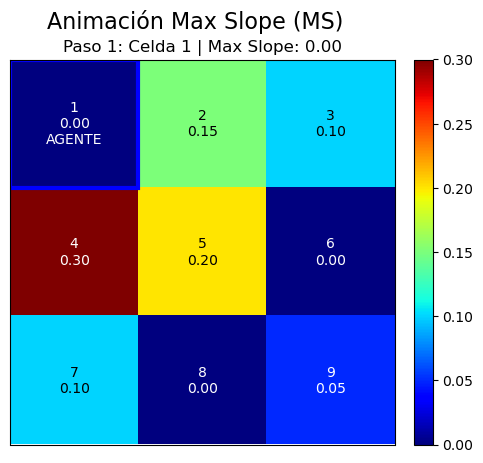

In [1102]:
# === MS ===
df_anim_ms = mejor_df_MS  # o df_ms_B
bk_series_ms = df_anim_ms["Bk"]

fig_ms, ax_ms = plt.subplots(figsize=(6, 5))
fig_ms.suptitle("Animación Max Slope (MS)", fontsize=16)
im_ms = ax_ms.imshow(bk_series_ms.iloc[0], cmap='jet', vmin=0, vmax=np.max(matriz))
fig_ms.colorbar(im_ms, ax=ax_ms, fraction=0.046, pad=0.04)
title_ms = ax_ms.set_title("")
text_objects_ms = []
border_ms = None

anim_func_ms = animation_1_Trajectory(df_anim_ms, ax_ms, im_ms, title_ms, text_objects_ms, border_ms, matriz)
ani_ms = FuncAnimation(fig_ms, anim_func_ms, frames=len(df_anim_ms), interval=1500, repeat=False)

rc('animation', html='html5')
HTML(ani_ms.to_html5_video())

## Artificial Bee Colony (ABC)

In [1103]:
# === Mutación auxiliar para ABC ===
def mutar_trayectoria(trayectoria, vecinos, nodo_inicial, max_pasos):
    """
    Realiza una mutación en una trayectoria existente para generar diversidad
    en el algoritmo ABC (Artificial Bee Colony).

    trayectoria: lista de nodos visitados
    vecinos: lista de vecinos válidos para cada nodo
    nodo_inicial: nodo de inicio (no se muta)
    max_pasos: número máximo de pasos permitidos
    """
    if len(trayectoria) < 2:  # Si la trayectoria es demasiado corta, no se muta
        return trayectoria

    nueva = trayectoria[:]  # Copia de la trayectoria original
    idx = random.randint(1, len(nueva) - 1)  # Elegir un índice al azar (no el inicial)
    anterior = nueva[idx - 1]  # Nodo anterior al índice elegido

    # Elegir un nuevo nodo aleatorio entre los vecinos del nodo anterior
    nuevos_candidatos = vecinos[anterior]
    if not nuevos_candidatos:  # Si no hay vecinos, retornar la trayectoria tal cual
        return nueva

    nuevo_nodo = random.choice(nuevos_candidatos)
    nueva = nueva[:idx] + [nuevo_nodo]  # Reemplaza el nodo seleccionado
    actual = nuevo_nodo
    visitados = set(nueva)  # Conjunto de nodos ya visitados
    pasos_restantes = (max_pasos - len(nueva)) if max_pasos else 100  # Limitar número de pasos

    # Construir el resto de la trayectoria desde el nuevo nodo
    while pasos_restantes > 0:
        candidatos = [n for n in vecinos[actual] if n not in visitados]  # Vecinos no visitados
        if not candidatos:  # Si no hay vecinos nuevos, considerar todos los vecinos
            candidatos = vecinos[actual]
        if not candidatos:  # Si no hay vecinos en absoluto, se termina la mutación
            break
        siguiente = random.choice(candidatos)  # Elegir siguiente nodo
        nueva.append(siguiente)
        visitados.add(siguiente)
        actual = siguiente
        pasos_restantes -= 1

    return nueva  # Devolver la trayectoria mutada

# === ABC ===
def ABC(
    func_objetivo,          # Función objetivo que evalúa la calidad de una trayectoria
    filas,                  # Número de filas del mapa
    columnas,               # Número de columnas del mapa
    nodo_inicial,           # Nodo inicial de cada abeja
    movimientos_objetivo,   # Movimientos permitidos para las abejas
    n_abejas=10,            # Número de abejas por iteración
    n_iter=100,             # Número de iteraciones
    limite=10,              # Límite de intentos sin mejora (no usado en esta versión)
    modo='min',             # 'min' para minimizar, 'max' para maximizar
    max_pasos=None          # Máximo número de pasos por abeja
):
    nodos = filas * columnas  # Número total de nodos

    # Funciones auxiliares para convertir entre índices lineales y coordenadas
    def idx_to_xy(idx):
        return idx // columnas, idx % columnas

    def xy_to_idx(x, y):
        return x * columnas + y

    # Construcción de la lista de vecinos para cada nodo
    vecinos = [[] for _ in range(nodos)]
    for idx in range(nodos):
        x, y = idx_to_xy(idx)
        for dx, dy in movimientos_objetivo:
            nx, ny = x + dx, y + dy
            if 0 <= nx < filas and 0 <= ny < columnas:
                vecinos[idx].append(xy_to_idx(nx, ny))

    # Inicialización de variables para almacenar la mejor solución
    mejor_trayectoria = None
    mejor_valor = float('inf') if modo == 'min' else -float('inf')
    mejor_data_pasos = None
    historial_valores = []

    # Bucle principal del ABC
    for iteracion in range(n_iter):
        for _ in range(n_abejas):
            no_visitados = set(range(nodos))  # Nodos no visitados por la abeja
            trayectoria = [nodo_inicial]      # Trayectoria inicial
            no_visitados.discard(nodo_inicial)
            actual = nodo_inicial

            # Construcción de la trayectoria de la abeja paso a paso
            while max_pasos is None or len(trayectoria) < max_pasos:
                candidatos = [n for n in vecinos[actual] if n in no_visitados]  # Vecinos no visitados
                if not candidatos:
                    candidatos = vecinos[actual]  # Si no hay no visitados, considerar todos
                    if not candidatos:           # Si no hay vecinos, terminar
                        break
                siguiente = np.random.choice(candidatos)  # Elegir nodo siguiente aleatoriamente
                trayectoria.append(siguiente)
                if siguiente in no_visitados:
                    no_visitados.remove(siguiente)
                actual = siguiente

            # Evaluar la trayectoria de la abeja
            valor, data_pasos = func_objetivo([x + 1 for x in trayectoria])

            # Actualizar mejor solución encontrada
            if (modo == 'min' and valor < mejor_valor) or (modo == 'max' and valor > mejor_valor):
                mejor_valor = valor
                mejor_trayectoria = np.array(trayectoria, dtype=int)
                mejor_data_pasos = data_pasos

        # Guardar el mejor valor de la iteración
        historial_valores.append(mejor_valor)

    # Devolver resultados: valor, trayectoria (índices 1-based), DataFrame de datos por pasos y historial
    df_resultado = pd.DataFrame(mejor_data_pasos)
    return mejor_valor, [int(x) + 1 for x in mejor_trayectoria], df_resultado, historial_valores


In [1104]:
# ==== MATRIZ BASE ====
matriz = np.array([
    [0.10, 0.15, 0.10],
    [0.30, 0.20, 0.00],
    [0.10, 0.00, 0.05]
])

# --- FUNCIONES OBJETIVO ---
def objetivo_ET(trayectoria):
    df_et, et_total = ET(trayectoria, matriz, actualizar=False)
    return et_total, df_et.to_dict(orient="records")

def objetivo_DTR(trayectoria):
    df_dtr, dtr_total = DTR(trayectoria, matriz, gamma=0.95, actualizar=False)
    return dtr_total, df_dtr.to_dict(orient="records")

def objetivo_MS(trayectoria):
    df_ms, max_slope = MS(trayectoria, matriz, actualizar=False)
    return max_slope, df_ms.to_dict(orient="records")

def objetivo_ME(trayectoria):
    df_me, entropia_final, _ = minimum_entropy(trayectoria, matriz, actualizar=False)
    return entropia_final, df_me.to_dict(orient="records")

# --- PARÁMETROS GENERALES ---
filas, columnas = matriz.shape
nodo_inicial = 0
max_pasos = 5
n_abejas = 20
n_iter = 5
limite = 5  # Número de ciclos sin mejora antes de reexplorar
movimientos_objetivo = [(1, 0), (-1, 0), (0, 1), (0, -1)]

# --- OPTIMIZACIÓN CON ABC ---
mejor_valor_ET, mejor_trayectoria_ET, mejor_df_ET, historial_ET = ABC(
    func_objetivo=objetivo_ET,
    filas=filas,
    columnas=columnas,
    nodo_inicial=nodo_inicial,
    movimientos_objetivo=movimientos_objetivo,
    n_abejas=n_abejas,
    n_iter=n_iter,
    limite=limite,
    modo='min',
    max_pasos=max_pasos
)

mejor_valor_DTR, mejor_trayectoria_DTR, mejor_df_DTR, historial_DTR = ABC(
    func_objetivo=objetivo_DTR,
    filas=filas,
    columnas=columnas,
    nodo_inicial=nodo_inicial,
    movimientos_objetivo=movimientos_objetivo,
    n_abejas=n_abejas,
    n_iter=n_iter,
    limite=limite,
    modo='max',
    max_pasos=max_pasos
)

mejor_valor_MS, mejor_trayectoria_MS, mejor_df_MS, historial_MS = ABC(
    func_objetivo=objetivo_MS,
    filas=filas,
    columnas=columnas,
    nodo_inicial=nodo_inicial,
    movimientos_objetivo=movimientos_objetivo,
    n_abejas=n_abejas,
    n_iter=n_iter,
    limite=limite,
    modo='max',
    max_pasos=max_pasos
)

mejor_valor_ME, mejor_trayectoria_ME, mejor_df_ME, historial_ME = ABC(
    func_objetivo=objetivo_ME,
    filas=filas,
    columnas=columnas,
    nodo_inicial=nodo_inicial,
    movimientos_objetivo=movimientos_objetivo,
    n_abejas=n_abejas,
    n_iter=n_iter,
    limite=limite,
    modo='min',
    max_pasos=max_pasos
)

# --- IMPRIMIR RESULTADOS ---
print("Mejor trayectoria (ET):", mejor_trayectoria_ET)
print("Valor mínimo ET:", mejor_valor_ET)

print("Mejor trayectoria (DTR):", mejor_trayectoria_DTR)
print("Valor máximo DTR:", mejor_valor_DTR)

print("Mejor trayectoria (MS):", mejor_trayectoria_MS)
print("Valor mínimo MS:", mejor_valor_MS)

print("Mejor trayectoria (ME):", mejor_trayectoria_ME)
print("Valor mínimo Entropía final:", mejor_valor_ME)


Mejor trayectoria (ET): [1, 4, 5, 2, 3]
Valor mínimo ET: 2.3
Mejor trayectoria (DTR): [1, 4, 5, 2, 3]
Valor máximo DTR: 0.7755568749999999
Mejor trayectoria (MS): [1, 4, 5, 2, 3]
Valor mínimo MS: 0.3
Mejor trayectoria (ME): [1, 4, 5, 2, 3]
Valor mínimo Entropía final: 0.5482892142331044


## Black Hole Algorithm (BHA)

In [1105]:
def BHA(
    func_objetivo,          # Función objetivo que evalúa la calidad de una trayectoria
    filas,                  # Número de filas del espacio de búsqueda
    columnas,               # Número de columnas del espacio de búsqueda
    nodo_inicial,           # Nodo inicial desde el que comienzan las "estrellas"
    movimientos_objetivo,   # Movimientos permitidos desde cada nodo, ej: [(0,1),(1,0),...]
    n_estrellas=10,         # Número de agentes (estrellas) por iteración
    n_iter=100,             # Número de iteraciones
    modo='min',             # 'min' para minimizar la función objetivo, 'max' para maximizar
    max_pasos=None          # Número máximo de pasos por estrella (None = ilimitado)
):
    nodos = filas * columnas  # Total de nodos en el mapa

    # Función auxiliar: convierte índice lineal a coordenadas (x, y)
    def idx_to_xy(idx):
        return idx // columnas, idx % columnas

    # Función auxiliar: convierte coordenadas (x, y) a índice lineal
    def xy_to_idx(x, y):
        return x * columnas + y

    # Construcción de lista de vecinos válidos para cada nodo
    vecinos = [[] for _ in range(nodos)]
    for idx in range(nodos):
        x, y = idx_to_xy(idx)
        for dx, dy in movimientos_objetivo:
            nx, ny = x + dx, y + dy
            if 0 <= nx < filas and 0 <= ny < columnas:  # Solo vecinos dentro del mapa
                vecinos[idx].append(xy_to_idx(nx, ny))

    # Inicialización de variables para almacenar la mejor trayectoria y su valor
    mejor_trayectoria = None
    mejor_valor = float('inf') if modo == 'min' else -float('inf')
    mejor_data_pasos = None
    historial_valores = []  # Registro del mejor valor por iteración

    # Bucle principal de iteraciones
    for iteracion in range(n_iter):
        # Cada estrella genera una trayectoria en cada iteración
        for _ in range(n_estrellas):
            no_visitados = set(range(nodos))  # Nodos no visitados por la estrella
            trayectoria = [nodo_inicial]      # Trayectoria inicial
            no_visitados.discard(nodo_inicial)
            actual = nodo_inicial

            # Construcción de la trayectoria paso a paso
            while max_pasos is None or len(trayectoria) < max_pasos:
                # Seleccionar candidatos no visitados
                candidatos = [n for n in vecinos[actual] if n in no_visitados]
                if not candidatos:
                    candidatos = vecinos[actual]  # Si no hay no visitados, considerar todos
                    if not candidatos:           # Si no hay vecinos, terminar trayectoria
                        break
                siguiente = np.random.choice(candidatos)  # Selección aleatoria del siguiente nodo
                trayectoria.append(siguiente)
                if siguiente in no_visitados:
                    no_visitados.remove(siguiente)
                actual = siguiente

            # Evaluar la trayectoria construida usando la función objetivo
            valor, data_pasos = func_objetivo([x + 1 for x in trayectoria])

            # Actualizar mejor solución encontrada si corresponde
            if (modo == 'min' and valor < mejor_valor) or (modo == 'max' and valor > mejor_valor):
                mejor_valor = valor
                mejor_trayectoria = np.array(trayectoria, dtype=int)
                mejor_data_pasos = data_pasos

        # Guardar el mejor valor de esta iteración en el historial
        historial_valores.append(mejor_valor)

    # Devolver resultados:
    # valor de la mejor trayectoria, trayectoria con índices 1-based,
    # DataFrame con datos por pasos, historial de mejores valores
    df_resultado = pd.DataFrame(mejor_data_pasos)
    return mejor_valor, [int(x) + 1 for x in mejor_trayectoria], df_resultado, historial_valores

In [1106]:
# ==== MATRIZ BASE ====
matriz = np.array([
    [0.10, 0.15, 0.10],
    [0.30, 0.20, 0.00],
    [0.10, 0.00, 0.05]
])

# --- FUNCIONES OBJETIVO ---
def objetivo_ET(trayectoria):
    df_et, et_total = ET(trayectoria, matriz, actualizar=False)
    return et_total, df_et  # devuelve valor + dataframe

def objetivo_DTR(trayectoria):
    df_dtr, dtr_total = DTR(trayectoria, matriz, gamma=0.95, actualizar=False)
    return dtr_total, df_dtr

def objetivo_MS(trayectoria):
    df_ms, max_slope = MS(trayectoria, matriz, actualizar=False)
    return max_slope, df_ms

def objetivo_ME(trayectoria):
    df_me, entropia_final, _ = minimum_entropy(trayectoria, matriz, actualizar=False)
    return entropia_final, df_me

# --- PARÁMETROS GENERALES ---
filas, columnas = matriz.shape
nodo_inicial = 0
max_pasos = 5
n_estrellas = 20
n_iter = 5
movimientos_objetivo = [(1, 0), (-1, 0), (0, 1), (0, -1)]

# --- OPTIMIZACIÓN CON BHA ---
mejor_valor_ET, mejor_trayectoria_ET, mejor_df_ET, historial_ET = BHA(
    func_objetivo=objetivo_ET,
    filas=filas,
    columnas=columnas,
    nodo_inicial=nodo_inicial,
    movimientos_objetivo=movimientos_objetivo,
    n_estrellas=n_estrellas,
    n_iter=n_iter,
    modo='min',
    max_pasos=max_pasos
)

mejor_valor_DTR, mejor_trayectoria_DTR, mejor_df_DTR, historial_DTR = BHA(
    func_objetivo=objetivo_DTR,
    filas=filas,
    columnas=columnas,
    nodo_inicial=nodo_inicial,
    movimientos_objetivo=movimientos_objetivo,
    n_estrellas=n_estrellas,
    n_iter=n_iter,
    modo='max',
    max_pasos=max_pasos
)

mejor_valor_MS, mejor_trayectoria_MS, mejor_df_MS, historial_MS = BHA(
    func_objetivo=objetivo_MS,
    filas=filas,
    columnas=columnas,
    nodo_inicial=nodo_inicial,
    movimientos_objetivo=movimientos_objetivo,
    n_estrellas=n_estrellas,
    n_iter=n_iter,
    modo='max',
    max_pasos=max_pasos
)

mejor_valor_ME, mejor_trayectoria_ME, mejor_df_ME, historial_ME = BHA(
    func_objetivo=objetivo_ME,
    filas=filas,
    columnas=columnas,
    nodo_inicial=nodo_inicial,
    movimientos_objetivo=movimientos_objetivo,
    n_estrellas=n_estrellas,
    n_iter=n_iter,
    modo='min',
    max_pasos=max_pasos
)

# --- IMPRIMIR RESULTADOS ---
print("Mejor trayectoria (ET):", mejor_trayectoria_ET)
print("Valor mínimo ET:", mejor_valor_ET)

print("Mejor trayectoria (DTR):", mejor_trayectoria_DTR)
print("Valor máximo DTR:", mejor_valor_DTR)

print("Mejor trayectoria (MS):", mejor_trayectoria_MS)
print("Valor mínimo MS:", mejor_valor_MS)

print("Mejor trayectoria (ME):", mejor_trayectoria_ME)
print("Valor mínimo Entropía final:", mejor_valor_ME)


Mejor trayectoria (ET): [1, 4, 5, 2, 3]
Valor mínimo ET: 2.3
Mejor trayectoria (DTR): [1, 4, 5, 2, 3]
Valor máximo DTR: 0.7755568749999999
Mejor trayectoria (MS): [1, 4, 7, 8, 9]
Valor mínimo MS: 0.3
Mejor trayectoria (ME): [1, 2, 5, 4, 7]
Valor mínimo Entropía final: 0.5482892142331044


# Búsqueda óptima con algoritmos bioinspirados con actualización de mapa con RBF

## Definición de funciones objetivo para los algoritmos bioinspirados con RBF

In [1107]:
# === pdmax = 0.8 ===

# ==== Función objetivo basada en ET con actualización RBF ====
def func_objetivo_ET_rbf2(trayectoria):
    df, et_total = ET(
        trayectoria=trayectoria,
        matriz_inicial=matriz,
        actualizar=True,
        modo_actualizacion='rbf',
        parametros_rbf=parametros_RBF2
    )
    return et_total, df   # <-- devuelve el DataFrame con los pasos

# ==== Función objetivo DTR con RBF ====
def func_objetivo_DTR_rbf2(trayectoria):
    df, dtr_total = DTR(
        trayectoria,
        matriz_inicial=matriz,
        gamma=0.95,
        actualizar=True,
        modo_actualizacion='rbf',
        parametros_rbf=parametros_RBF2
    )
    return dtr_total, df

# ==== Función objetivo Maximum Slope (MS) con RBF ====
def func_objetivo_MS_rbf2(trayectoria):
    df, max_slope = MS(
        trayectoria,
        matriz_inicial=matriz,
        actualizar=True,
        modo_actualizacion='rbf',
        parametros_rbf=parametros_RBF2
    )
    return max_slope, df

# ==== Función objetivo Minimum Entropy (MinEnt) con RBF ====
def func_objetivo_MinEnt_rbf2(trayectoria):
    df, entropia_final, entropia_inicial = minimum_entropy(
        trayectoria,
        matriz_inicial=matriz,
        actualizar=True,
        modo_actualizacion='rbf',
        parametros_rbf=parametros_RBF2
    )
    return entropia_final, df


# === pdmax = 1 ===
# ==== Función objetivo basada en ET con actualización RBF ====
def func_objetivo_ET_rbf1(trayectoria):
    df, et_total = ET(
        trayectoria=trayectoria,
        matriz_inicial=matriz,
        actualizar=True,
        modo_actualizacion='rbf',
        parametros_rbf=parametros_RBF
    )
    return et_total, df   # <-- devuelve el DataFrame con los pasos

# ==== Función objetivo DTR con RBF ====
def func_objetivo_DTR_rbf1(trayectoria):
    df, dtr_total = DTR(
        trayectoria,
        matriz_inicial=matriz,
        gamma=0.95,
        actualizar=True,
        modo_actualizacion='rbf',
        parametros_rbf=parametros_RBF
    )
    return dtr_total, df

# ==== Función objetivo Maximum Slope (MS) con RBF ====
def func_objetivo_MS_rbf1(trayectoria):
    df, max_slope = MS(
        trayectoria,
        matriz_inicial=matriz,
        actualizar=True,
        modo_actualizacion='rbf',
        parametros_rbf=parametros_RBF
    )
    return max_slope, df

# ==== Función objetivo Minimum Entropy (MinEnt) con RBF ====
def func_objetivo_MinEnt_rbf1(trayectoria):
    df, entropia_final, entropia_inicial = minimum_entropy(
        trayectoria,
        matriz_inicial=matriz,
        actualizar=True,
        modo_actualizacion='rbf',
        parametros_rbf=parametros_RBF
    )
    return entropia_final, df

## Búsqueda con algoritmos bioinspirados con actualización de mapa con RBF (pdmax = 0.8)

In [1108]:
# ==== MATRIZ BASE ====
matriz = np.array([
    [0.10, 0.15, 0.10],
    [0.30, 0.20, 0.00],
    [0.10, 0.00, 0.05]
])

# Movimientos permitidos (4 vecinos)
movimientos = [(-1, 0), (1, 0), (0, -1), (0, 1)]

# Parámetros comunes
n_iter = 20
n_agentes = 20
max_pasos = 5
alfa = 1.0
beta = 2.0
rho = 0.1
Q = 1.0

# ==== EJECUCIÓN DE ALGORITMOS PARA CADA FUNCIÓN OBJETIVO ====

# --- ET ---
ACO_ET_df2, ACO_ET_valor2, ACO_ET_tray2, ACO_ET_hist2 = ACO(
    func_objetivo=func_objetivo_ET_rbf2,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_hormigas=n_agentes,
    n_iter=n_iter,
    alfa=alfa,
    beta=beta,
    rho=rho,
    Q=Q,
    modo='min',
    max_pasos=max_pasos
)

ABC_ET_valor2, ABC_ET_tray2, ABC_ET_df2, ABC_ET_hist2 = ABC(
    func_objetivo=func_objetivo_ET_rbf2,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_abejas=n_agentes,
    n_iter=n_iter,
    limite=10,
    modo='min',
    max_pasos=max_pasos
)

BHA_ET_valor2, BHA_ET_tray2, BHA_ET_df2, BHA_ET_hist2 = BHA(
    func_objetivo=func_objetivo_ET_rbf2,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_estrellas=n_agentes,
    n_iter=n_iter,
    modo='min',
    max_pasos=max_pasos
)

# --- DTR ---
ACO_DTR_df2, ACO_DTR_valor2, ACO_DTR_tray2, ACO_DTR_hist2 = ACO(
    func_objetivo=func_objetivo_DTR_rbf2,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_hormigas=n_agentes,
    n_iter=n_iter,
    alfa=alfa,
    beta=beta,
    rho=rho,
    Q=Q,
    modo='min',
    max_pasos=max_pasos
)

ABC_DTR_valor2, ABC_DTR_tray2, ABC_DTR_df2, ABC_DTR_hist2 = ABC(
    func_objetivo=func_objetivo_DTR_rbf2,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_abejas=n_agentes,
    n_iter=n_iter,
    limite=10,
    modo='min',
    max_pasos=max_pasos
)

BHA_DTR_valor2, BHA_DTR_tray2, BHA_DTR_df2, BHA_DTR_hist2 = BHA(
    func_objetivo=func_objetivo_DTR_rbf2,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_estrellas=n_agentes,
    n_iter=n_iter,
    modo='min',
    max_pasos=max_pasos
)

# --- MS ---
ACO_MS_df2, ACO_MS_valor2, ACO_MS_tray2, ACO_MS_hist2 = ACO(
    func_objetivo=func_objetivo_MS_rbf2,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_hormigas=n_agentes,
    n_iter=n_iter,
    alfa=alfa,
    beta=beta,
    rho=rho,
    Q=Q,
    modo='min',
    max_pasos=max_pasos
)

ABC_MS_valor2, ABC_MS_tray2, ABC_MS_df2, ABC_MS_hist2 = ABC(
    func_objetivo=func_objetivo_MS_rbf2,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_abejas=n_agentes,
    n_iter=n_iter,
    limite=10,
    modo='min',
    max_pasos=max_pasos
)

BHA_MS_valor2, BHA_MS_tray2, BHA_MS_df2, BHA_MS_hist2 = BHA(
    func_objetivo=func_objetivo_MS_rbf2,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_estrellas=n_agentes,
    n_iter=n_iter,
    modo='min',
    max_pasos=max_pasos
)

# --- MinEnt ---
ACO_MinEnt_df2, ACO_MinEnt_valor2, ACO_MinEnt_tray2, ACO_MinEnt_hist2 = ACO(
    func_objetivo=func_objetivo_MinEnt_rbf2,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_hormigas=n_agentes,
    n_iter=n_iter,
    alfa=alfa,
    beta=beta,
    rho=rho,
    Q=Q,
    modo='min',
    max_pasos=max_pasos
)

ABC_MinEnt_valor2, ABC_MinEnt_tray2, ABC_MinEnt_df2, ABC_MinEnt_hist2 = ABC(
    func_objetivo=func_objetivo_MinEnt_rbf2,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_abejas=n_agentes,
    n_iter=n_iter,
    limite=10,
    modo='min',
    max_pasos=max_pasos
)

BHA_MinEnt_valor2, BHA_MinEnt_tray2, BHA_MinEnt_df2, BHA_MinEnt_hist2 = BHA(
    func_objetivo=func_objetivo_MinEnt_rbf2,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_estrellas=n_agentes,
    n_iter=n_iter,
    modo='min',
    max_pasos=max_pasos
)

In [1109]:
# ==== ET ====
print("===== ET =====")
print(f"ACO: Valor = {ACO_ET_valor2:.4f}, Trayectoria = {ACO_ET_tray2}")
print(f"ABC: Valor = {ABC_ET_valor2:.4f}, Trayectoria = {ABC_ET_tray2}")
print(f"BHA: Valor = {BHA_ET_valor2:.4f}, Trayectoria = {BHA_ET_tray2}")

# ==== DTR ====
print("===== DTR =====")
print(f"ACO: Valor = {ACO_DTR_valor2:.4f}, Trayectoria = {ACO_DTR_tray2}")
print(f"ABC: Valor = {ABC_DTR_valor2:.4f}, Trayectoria = {ABC_DTR_tray2}")
print(f"BHA: Valor = {BHA_DTR_valor2:.4f}, Trayectoria = {BHA_DTR_tray2}")

# ==== MS ====
print("===== MS =====")
print(f"ACO: Valor = {ACO_MS_valor2:.4f}, Trayectoria = {ACO_MS_tray2}")
print(f"ABC: Valor = {ABC_MS_valor2:.4f}, Trayectoria = {ABC_MS_tray2}")
print(f"BHA: Valor = {BHA_MS_valor2:.4f}, Trayectoria = {BHA_MS_tray2}")

# ==== MinEnt ====
print("===== MinEnt =====")
print(f"ACO: Valor = {ACO_MinEnt_valor2:.4f}, Trayectoria = {ACO_MinEnt_tray2}")
print(f"ABC: Valor = {ABC_MinEnt_valor2:.4f}, Trayectoria = {ABC_MinEnt_tray2}")
print(f"BHA: Valor = {BHA_MinEnt_valor2:.4f}, Trayectoria = {BHA_MinEnt_tray2}")


===== ET =====
ACO: Valor = 3.7413, Trayectoria = [1, 4, 5, 2, 3]
ABC: Valor = 3.7413, Trayectoria = [1, 4, 5, 2, 3]
BHA: Valor = 3.7413, Trayectoria = [1, 4, 5, 2, 3]
===== DTR =====
ACO: Valor = 0.4243, Trayectoria = [1, 2, 3, 6, 9]
ABC: Valor = 0.4243, Trayectoria = [1, 2, 3, 6, 9]
BHA: Valor = 0.4243, Trayectoria = [1, 2, 3, 6, 9]
===== MS =====
ACO: Valor = 0.3333, Trayectoria = [1, 4, 7, 8, 5]
ABC: Valor = 0.1413, Trayectoria = [1, 2, 3, 6, 9]
BHA: Valor = 0.1413, Trayectoria = [1, 2, 3, 6, 9]
===== MinEnt =====
ACO: Valor = 2.0342, Trayectoria = [1, 2, 3, 6, 9]
ABC: Valor = 2.0342, Trayectoria = [1, 2, 3, 6, 9]
BHA: Valor = 2.0342, Trayectoria = [1, 2, 3, 6, 9]


## Búsqueda con algoritmos bioinspirados con actualización de mapa con RBF (pdmax = 1)

In [1110]:
# ==== MATRIZ BASE ====
matriz = np.array([
    [0.10, 0.15, 0.10],
    [0.30, 0.20, 0.00],
    [0.10, 0.00, 0.05]
])

# Movimientos permitidos (4 vecinos)
movimientos = [(-1, 0), (1, 0), (0, -1), (0, 1)]

# Parámetros comunes
n_iter = 20
n_agentes = 20
max_pasos = 5
alfa = 1.0
beta = 2.0
rho = 0.1
Q = 1.0

# ==== EJECUCIÓN DE ALGORITMOS PARA CADA FUNCIÓN OBJETIVO ====

# --- ET ---
ACO_ET_df1, ACO_ET_valor1, ACO_ET_tray1, ACO_ET_hist1 = ACO(
    func_objetivo=func_objetivo_ET_rbf1,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_hormigas=n_agentes,
    n_iter=n_iter,
    alfa=alfa,
    beta=beta,
    rho=rho,
    Q=Q,
    modo='min',
    max_pasos=max_pasos
)

ABC_ET_valor1, ABC_ET_tray1, ABC_ET_df1, ABC_ET_hist1 = ABC(
    func_objetivo=func_objetivo_ET_rbf1,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_abejas=n_agentes,
    n_iter=n_iter,
    limite=10,
    modo='min',
    max_pasos=max_pasos
)

BHA_ET_valor1, BHA_ET_tray1, BHA_ET_df1, BHA_ET_hist1 = BHA(
    func_objetivo=func_objetivo_ET_rbf1,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_estrellas=n_agentes,
    n_iter=n_iter,
    modo='min',
    max_pasos=max_pasos
)

# --- DTR ---
ACO_DTR_df1, ACO_DTR_valor1, ACO_DTR_tray1, ACO_DTR_hist1 = ACO(
    func_objetivo=func_objetivo_DTR_rbf1,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_hormigas=n_agentes,
    n_iter=n_iter,
    alfa=alfa,
    beta=beta,
    rho=rho,
    Q=Q,
    modo='min',
    max_pasos=max_pasos
)

ABC_DTR_valor1, ABC_DTR_tray1, ABC_DTR_df1, ABC_DTR_hist1 = ABC(
    func_objetivo=func_objetivo_DTR_rbf1,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_abejas=n_agentes,
    n_iter=n_iter,
    limite=10,
    modo='min',
    max_pasos=max_pasos
)

BHA_DTR_valor1, BHA_DTR_tray1, BHA_DTR_df1, BHA_DTR_hist1 = BHA(
    func_objetivo=func_objetivo_DTR_rbf1,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_estrellas=n_agentes,
    n_iter=n_iter,
    modo='min',
    max_pasos=max_pasos
)

# --- MS ---
ACO_MS_df1, ACO_MS_valor1, ACO_MS_tray1, ACO_MS_hist1 = ACO(
    func_objetivo=func_objetivo_MS_rbf1,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_hormigas=n_agentes,
    n_iter=n_iter,
    alfa=alfa,
    beta=beta,
    rho=rho,
    Q=Q,
    modo='min',
    max_pasos=max_pasos
)

ABC_MS_valor1, ABC_MS_tray1, ABC_MS_df1, ABC_MS_hist1 = ABC(
    func_objetivo=func_objetivo_MS_rbf1,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_abejas=n_agentes,
    n_iter=n_iter,
    limite=10,
    modo='min',
    max_pasos=max_pasos
)

BHA_MS_valor1, BHA_MS_tray1, BHA_MS_df1, BHA_MS_hist1 = BHA(
    func_objetivo=func_objetivo_MS_rbf1,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_estrellas=n_agentes,
    n_iter=n_iter,
    modo='min',
    max_pasos=max_pasos
)

# --- MinEnt ---
ACO_MinEnt_df1, ACO_MinEnt_valor1, ACO_MinEnt_tray1, ACO_MinEnt_hist1 = ACO(
    func_objetivo=func_objetivo_MinEnt_rbf1,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_hormigas=n_agentes,
    n_iter=n_iter,
    alfa=alfa,
    beta=beta,
    rho=rho,
    Q=Q,
    modo='min',
    max_pasos=max_pasos
)

ABC_MinEnt_valor1, ABC_MinEnt_tray1, ABC_MinEnt_df1, ABC_MinEnt_hist1 = ABC(
    func_objetivo=func_objetivo_MinEnt_rbf1,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_abejas=n_agentes,
    n_iter=n_iter,
    limite=10,
    modo='min',
    max_pasos=max_pasos
)

BHA_MinEnt_valor1, BHA_MinEnt_tray1, BHA_MinEnt_df1, BHA_MinEnt_hist1 = BHA(
    func_objetivo=func_objetivo_MinEnt_rbf1,
    filas=matriz.shape[0],
    columnas=matriz.shape[1],
    nodo_inicial=0,
    movimientos_objetivo=movimientos,
    n_estrellas=n_agentes,
    n_iter=n_iter,
    modo='min',
    max_pasos=max_pasos
)

In [1111]:
# ==== ET ====
print("===== ET =====")
print(f"ACO: Valor = {ACO_ET_valor1:.4f}, Trayectoria = {ACO_ET_tray1}")
print(f"ABC: Valor = {ABC_ET_valor1:.4f}, Trayectoria = {ABC_ET_tray1}")
print(f"BHA: Valor = {BHA_ET_valor1:.4f}, Trayectoria = {BHA_ET_tray1}")

# ==== DTR ====
print("===== DTR =====")
print(f"ACO: Valor = {ACO_DTR_valor1:.4f}, Trayectoria = {ACO_DTR_tray1}")
print(f"ABC: Valor = {ABC_DTR_valor1:.4f}, Trayectoria = {ABC_DTR_tray1}")
print(f"BHA: Valor = {BHA_DTR_valor1:.4f}, Trayectoria = {BHA_DTR_tray1}")

# ==== MS ====
print("===== MS =====")
print(f"ACO: Valor = {ACO_MS_valor1:.4f}, Trayectoria = {ACO_MS_tray1}")
print(f"ABC: Valor = {ABC_MS_valor1:.4f}, Trayectoria = {ABC_MS_tray1}")
print(f"BHA: Valor = {BHA_MS_valor1:.4f}, Trayectoria = {BHA_MS_tray1}")

# ==== MinEnt ====
print("===== MinEnt =====")
print(f"ACO: Valor = {ACO_MinEnt_valor1:.4f}, Trayectoria = {ACO_MinEnt_tray1}")
print(f"ABC: Valor = {ABC_MinEnt_valor1:.4f}, Trayectoria = {ABC_MinEnt_tray1}")
print(f"BHA: Valor = {BHA_MinEnt_valor1:.4f}, Trayectoria = {BHA_MinEnt_tray1}")

===== ET =====
ACO: Valor = 3.4585, Trayectoria = [1, 4, 5, 2, 3]
ABC: Valor = 3.4585, Trayectoria = [1, 4, 5, 2, 3]
BHA: Valor = 3.4585, Trayectoria = [1, 4, 5, 2, 3]
===== DTR =====
ACO: Valor = 0.4413, Trayectoria = [1, 2, 3, 6, 9]
ABC: Valor = 0.4413, Trayectoria = [1, 2, 3, 6, 9]
BHA: Valor = 0.4413, Trayectoria = [1, 2, 3, 6, 9]
===== MS =====
ACO: Valor = 0.4000, Trayectoria = [1, 4, 7, 8, 5]
ABC: Valor = 0.1667, Trayectoria = [1, 2, 3, 6, 9]
BHA: Valor = 0.1667, Trayectoria = [1, 2, 3, 6, 9]
===== MinEnt =====
ACO: Valor = 0.9259, Trayectoria = [1, 4, 5, 2, 3]
ABC: Valor = 0.9259, Trayectoria = [1, 2, 5, 4, 7]
BHA: Valor = 0.9259, Trayectoria = [1, 2, 5, 4, 7]


In [1112]:
def extraer_valor(x):
    if isinstance(x, (int, float, np.floating)):  # número directo
        return x
    if hasattr(x, "iloc"):  # es un DataFrame o Series
        try:
            return x.iloc[0,0]  # primera celda
        except:
            return x.iloc[0]   # primer valor de la primera columna
    return float(x)  # fallback

# ==== ET ====
print("===== ET =====")
print(f"ACO: Valor = {extraer_valor(ACO_ET_valor1):.4f}, Trayectoria = {ACO_ET_tray1}")
print(f"ABC: Valor = {extraer_valor(ABC_ET_valor1):.4f}, Trayectoria = {ABC_ET_tray1}")
print(f"BHA: Valor = {extraer_valor(BHA_ET_valor1):.4f}, Trayectoria = {BHA_ET_tray1}")

# ==== DTR ====
print("===== DTR =====")
print(f"ACO: Valor = {extraer_valor(ACO_DTR_valor1):.4f}, Trayectoria = {ACO_DTR_tray1}")
print(f"ABC: Valor = {extraer_valor(ABC_DTR_valor1):.4f}, Trayectoria = {ABC_DTR_tray1}")
print(f"BHA: Valor = {extraer_valor(BHA_DTR_valor1):.4f}, Trayectoria = {BHA_DTR_tray1}")

# ==== MS ====
print("===== MS =====")
print(f"ACO: Valor = {extraer_valor(ACO_MS_valor1):.4f}, Trayectoria = {ACO_MS_tray1}")
print(f"ABC: Valor = {extraer_valor(ABC_MS_valor1):.4f}, Trayectoria = {ABC_MS_tray1}")
print(f"BHA: Valor = {extraer_valor(BHA_MS_valor1):.4f}, Trayectoria = {BHA_MS_tray1}")

# ==== MinEnt ====
print("===== MinEnt =====")
print(f"ACO: Valor = {extraer_valor(ACO_MinEnt_valor1):.4f}, Trayectoria = {ACO_MinEnt_tray1}")
print(f"ABC: Valor = {extraer_valor(ABC_MinEnt_valor1):.4f}, Trayectoria = {ABC_MinEnt_tray1}")
print(f"BHA: Valor = {extraer_valor(BHA_MinEnt_valor1):.4f}, Trayectoria = {BHA_MinEnt_tray1}")


===== ET =====
ACO: Valor = 3.4585, Trayectoria = [1, 4, 5, 2, 3]
ABC: Valor = 3.4585, Trayectoria = [1, 4, 5, 2, 3]
BHA: Valor = 3.4585, Trayectoria = [1, 4, 5, 2, 3]
===== DTR =====
ACO: Valor = 0.4413, Trayectoria = [1, 2, 3, 6, 9]
ABC: Valor = 0.4413, Trayectoria = [1, 2, 3, 6, 9]
BHA: Valor = 0.4413, Trayectoria = [1, 2, 3, 6, 9]
===== MS =====
ACO: Valor = 0.4000, Trayectoria = [1, 4, 7, 8, 5]
ABC: Valor = 0.1667, Trayectoria = [1, 2, 3, 6, 9]
BHA: Valor = 0.1667, Trayectoria = [1, 2, 3, 6, 9]
===== MinEnt =====
ACO: Valor = 0.9259, Trayectoria = [1, 4, 5, 2, 3]
ABC: Valor = 0.9259, Trayectoria = [1, 2, 5, 4, 7]
BHA: Valor = 0.9259, Trayectoria = [1, 2, 5, 4, 7]


## Visualizaciones gráficas

In [1113]:
def plot_obj_vs_iter(hist_aco, hist_abc, hist_bha, nombre_objetivo):
    min_len = min(len(hist_aco), len(hist_abc), len(hist_bha))
    iteraciones = list(range(1, min_len + 1))

    plt.figure(figsize=(8,5))
    plt.plot(iteraciones, hist_aco[:min_len], 'r-o', label='ACO')
    plt.plot(iteraciones, hist_abc[:min_len], 'g-s', label='ABC')
    plt.plot(iteraciones, hist_bha[:min_len], 'b-^', label='BHA')
    plt.xlabel("Iteración")
    plt.ylabel(f"Valor objetivo ({nombre_objetivo})")
    plt.title(f"Evolución de {nombre_objetivo} con ACO, ABC y BHA")
    plt.legend()
    plt.grid(True)

    # Forzar que el eje X muestre solo enteros
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.show()


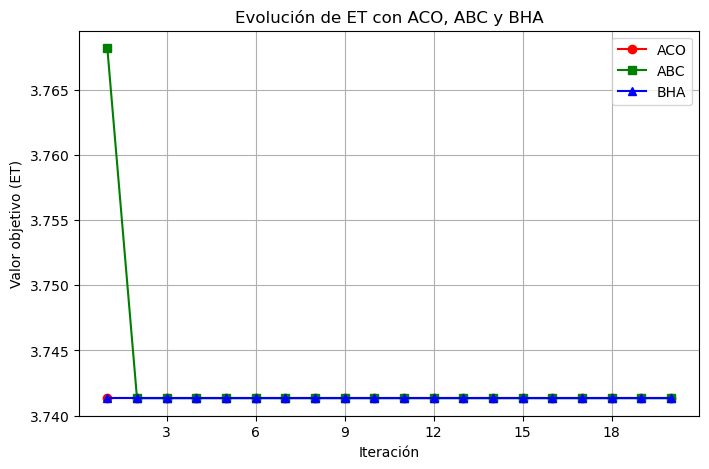

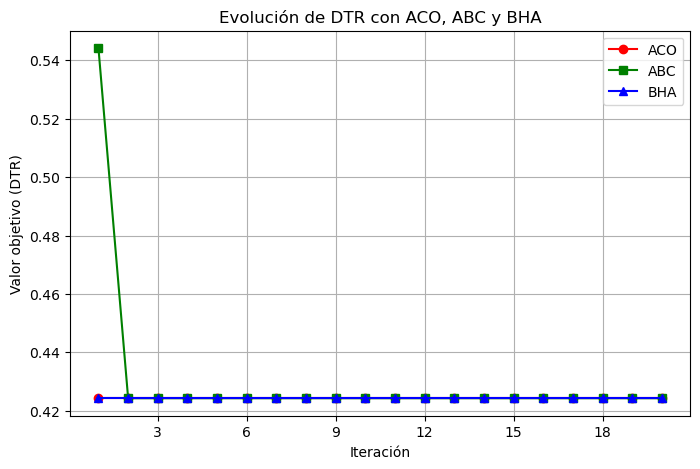

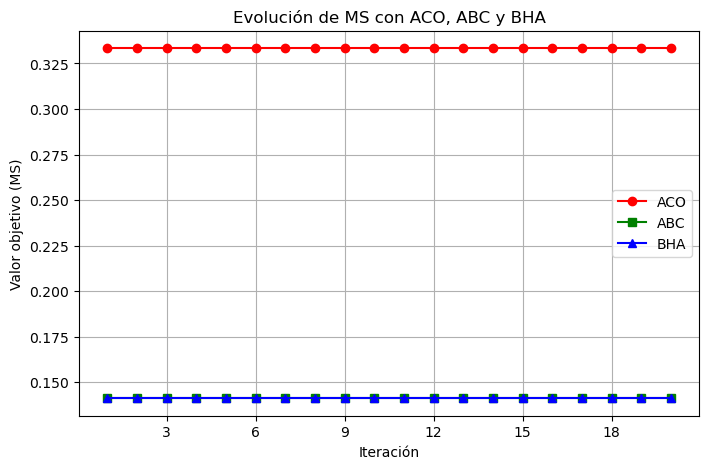

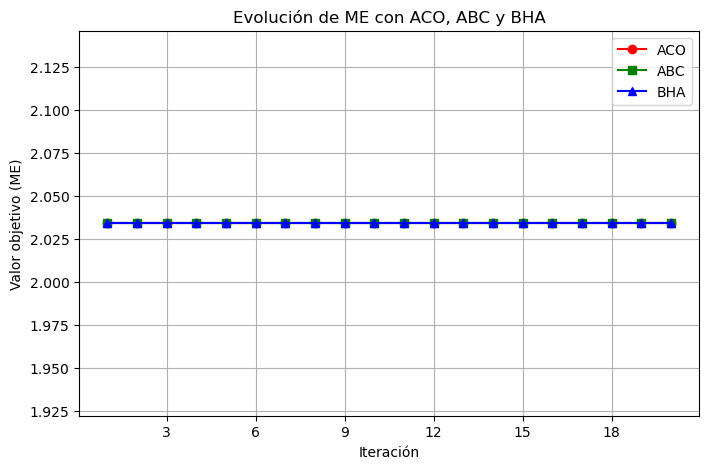

In [1114]:
plot_obj_vs_iter(ACO_ET_hist2, ABC_ET_hist2, BHA_ET_hist2, "ET")
plot_obj_vs_iter(ACO_DTR_hist2, ABC_DTR_hist2, BHA_DTR_hist2, "DTR")
plot_obj_vs_iter(ACO_MS_hist2, ABC_MS_hist2, BHA_MS_hist2, "MS")
plot_obj_vs_iter(ACO_MinEnt_hist2, ABC_MinEnt_hist2, BHA_MinEnt_hist2, "ME")

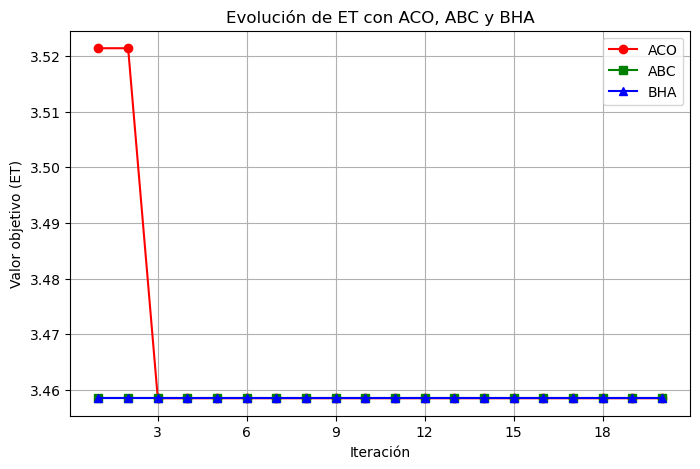

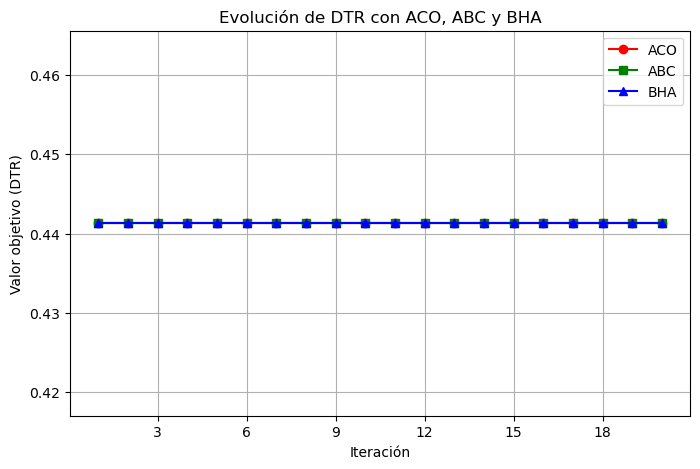

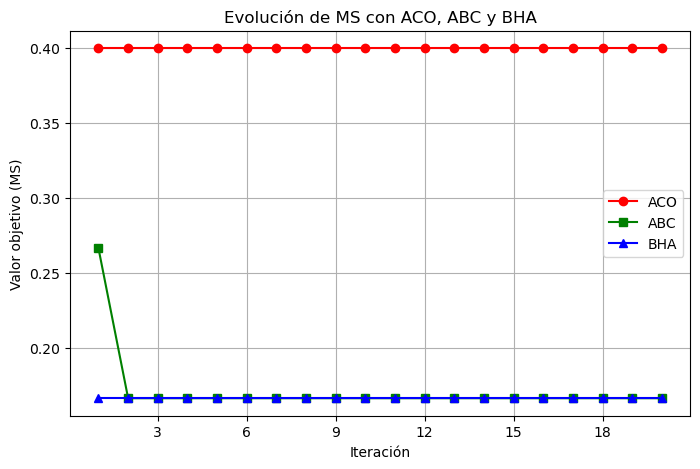

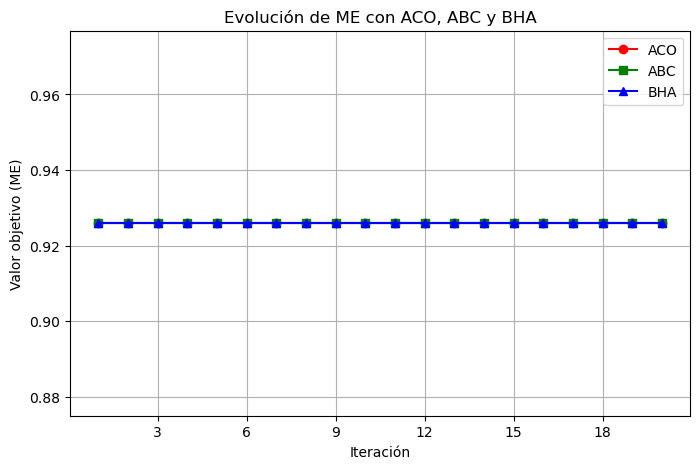

In [1115]:
plot_obj_vs_iter(ACO_ET_hist1, ABC_ET_hist1, BHA_ET_hist1, "ET")
plot_obj_vs_iter(ACO_DTR_hist1, ABC_DTR_hist1, BHA_DTR_hist1, "DTR")
plot_obj_vs_iter(ACO_MS_hist1, ABC_MS_hist1, BHA_MS_hist1, "MS")
plot_obj_vs_iter(ACO_MinEnt_hist1, ABC_MinEnt_hist1, BHA_MinEnt_hist1, "ME")

# Generador aleatorio de matrices para comparar la minimización/maximización de los algoritmos voraces contra los algoritmos bioinspirados

In [1116]:
# Generar una matriz de 3x3 con valores aleatorios uniformes
matriz = np.random.rand(50 ,50)

# Normalizar toda la matriz para que la suma total sea 1
matriz_normalizada = matriz / matriz.sum()

# Imprimir la matriz original y la normalizada
# print("🔹 Matriz aleatoria original:")
# print(matriz)
# print("\nMatriz normalizada globalmente (suma total = 1):")
# print(matriz_normalizada)


### Comparación